# Lab 3 · The missing filter labels
**Computer Vision · Mohammad Sabokrou · New Uzbekistan University**  
**120-minute core + optional 20-minute investigation · Individual work · Simple coding · 20 marks**

**Case file:** a vision laboratory has lost the labels on eight image-processing tools. Your job is to recover four assigned identities, discover a faulty edge pipeline, and defend a repair. A convincing answer needs evidence—not just a filter name.

Can you remove unwanted image changes without destroying the information your task needs?

Based on **Session03_Filtering_and_Edges_Revised(1).pptx**. Fourier filtering is used through ready-made functions: **no Fourier formulas, derivations, or FFT implementation are required**. A few small spatial calculations check understanding; most work is prediction, comparison, and explanation.

### How to work
1. Enter your own student ID. Your images, noise, patch, thresholds and changed case are reproducible.
2. Write each **prediction before running** its experiment. Keep wrong predictions and explain what changed your mind.
3. Run supplied code. In **YOUR TURN** cells, change only a setting or write one or two function calls. All sections run independently after setup.
4. Support answers with a named image region (row/column or visible landmark), a parameter, and an observation. “Looks better” is insufficient.
5. Write reasoning in your own words. If using AI for coding help, record what help you used; do not use it to supply predictions or explanations. Be ready to explain one result orally.

| Part | Lecture connection | Minutes | Marks |
|---|---|---:|---:|
| Setup | Student-specific assignment | 5 | — |
| 1 | Neighbours, convolution, padding, shape | 12 | 3 |
| 2 | Mean, Gaussian, median, bilateral | 18 | 3 |
| 3 | Detail residual, sharpening, separability | 10 | 2 |
| 4 | Fourier low/high-pass, families, band/notch | 15 | 3 |
| 5 | Mystery Sobel and related filters; diagnose a faulty pipeline | 25 | 3 |
| 6 | Canny: thinning, linking, parameters | 15 | 3 |
| 7 | Changed case and independent exit questions | 15 | 3 |
| Finish | Save and check submission | 5 | — |

**Marks reward reasoning:** within each part, approximately two-thirds for correct reasoning supported by evidence and one-third for completing the experiment. An honest revised prediction can earn full credit. These are this lab's marks, not changes to course assessment weights.


## Setup · Run the two cells below
Images are embedded from the same sample-photo collection as Lab 2. No image downloads, GPU, or API key are needed. Use Google Colab or Python with NumPy, SciPy, Matplotlib and Pillow. If a local installation lacks these, install `numpy scipy matplotlib pillow` once.

The helper cell is supplied infrastructure. **Do not study or reimplement it.** Values are floating-point grayscale in [0,1]; signed responses stay signed. Ordinary spatial filters use SciPy `reflect` padding (edge sample repeated). Fourier helpers use NumPy reflection padding (edge sample not repeated), crop back to the image, and retain phase. This difference matters if comparing borders exactly.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.signal import convolve2d
from PIL import Image
import hashlib, base64, io, json
plt.rcParams.update({'figure.dpi':100, 'font.size':10})
PHOTO_DATA = {'astronaut': '...', 'coffee': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAkGBwgHBgkIBwgKCgkLDRYPDQwMDRsUFRAWIB0iIiAdHx8kKDQsJCYxJx8fLT0tMTU3Ojo6Iys/RD84QzQ5Ojf/2wBDAQoKCg0MDRoPDxo3JR8lNzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzf/wAARCADIASwDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwDxsVMo4pirzTyewrNmiHZ7U4N2pF4FBpDHZpQc0zNKoOaQx9KBSqMkDqa1bDS2Z0a4Xr0j7n61E5qKuzSnSlUdolWzsZboggbUz94/0rcsdOVW2wjAB5c1oWtmWO1iqheNo9K0FiVEAO35e3QCvPq4hy0R69HCxpavVkdpZRRsS/JJ5J7/AEqxMmxW3MFBHyqD0+tN88sdsSAe5GSf8KY5SLBYb5D0AGa51ds6HpuO8ouAXY7R69T/AIVG86xkLGDwOw/lTJbkIWaQbnx9zPA+tU5BNdyFg55HODjAq1EhtsWcsX5BQHkY5Jp8diZELTfIpOcdDW9oPhPUb3bJFC+ztNN8q/h3NdhZeAIBh9QvHkP92MBF/M81tGlUl8KMJ4inD4mefLKsahIlUKP4RTTIZjkjjPWvWIPCfh62/wCXSNz6yMzH+dWhpOhKMfYLXH/XFav6o+rRj9eh0izyAgZyTnj8qcYyQDuAFeuPougyrtaxtse0YH8qp3Hg3Q7jPlI0R/2JCP0OaTwcujQ1j6fVNHmEUBA3EfL/ADp7AgZPA6V21/4CmX57K7VwOkcq4/UVy+p6Xe2DgXlu8Q6bzyp+hHFc9SjUh8SOqniKdT4WVIUVDvdwD6kdKe7uCTyxHGRUDYZCpAwBnJ7fWkSXdtSMnBHLeo/oKy3NbEx29W5I5x2H+NBJ4Y5NBwFCAdOtHlkrhBTSE2PX58ggYqRsL1OKhEbRgYPHc1GZt2R29TTFa5Z3BvpQjqW285qKJWwcd+lTJESmThTnmhCaRKg8s8fMfU1LCxd8E8jue1QxqSRuOB2qdgoGQQMelNEtdx7JtPyjJqeKcBCmfr71T884Cjp604KZMbOWHYVokZSLW5hgjpmr9tEswBb73as1DsI8zjPG7tWjBMsPMuRjp71aRjJl2ODCFWABB+8aYJyvCqSB3pZbjeq7z14AFNSF5BuaQp6KB0puxn6nziDil6mkBoJr0zzh+KMHNNUnNOzQMM4qe2hluZAkS5P8qtWWmSz7XkBRD69TXT2enxRhFjAQDsOrGuariIw0W524fByqay0RT0zS1t2+b5pT3xnH0rajRVIHlEE8cdW+lWFWNQwVlB6fL/jSbGkIwxCkYJHVvp7V5s6jm7s9eFONNWihGQBhjbkdQOg+p9aApkOS21P72P5VIyJEMSbSB0QHj6k1E0jSg8be47cf0FJLqDl2FlmS2xCi7SeSTyT9f8KgM6rKBk+YfbLY/oPag7N58pdzEcv/AHfpV/StKlnnSNEzLK2FXufr6CtLIyb7kOmaTLqk6xwqX3H5VUdfc+gr0vQvCNlpyJNeIk9wOcY+RPoO/wBTWjoekW+j2oRApmYfvJAOp9B7VBq+qiAFEOW/lXZGEaa5pbnnVa8qr5YaI0LrUIrZeWAx0FY9xrUkhPl8D1NYklw8zlnJJoWQelRKs2KNFI0jeTSHlzQJXPVjVJZB71Mjg9GqVIrlLiyuP4jU0d3IvfNVFf1qRSD0NWmQ0atvqZDAElRV8TwXUbRzKrK3B4yD9RXOipI5GjOVNaxqNGUqaexU8Q+CIbhPO0shCOfIJ+Rvp6H68Vw09pLbSGOaMxSIfmBGCK9Ys77JwcD1HY1W8R6Bb63a7kIjuVHySf0PqKzq4eNRc0NGdFDFypvlqarueXx5fIAOe9TFowfvNj0z1omhktJnt5wY5EO1lNVpFfzeOlefZnqaMszbXXklVHpVZI2bO7GB0FTqQseCM0iKVfB79TimCFjGAOmasAbvvN09OlMMZXnHB7dz/wDWpjYPy547CkgZa3Atj/JqJ9xOD90VUVSrEq5B9M9KsK6kDeccc5rVIxbHiIzEsD9BU8QaF1Cnr3NV1lH8HSp4pBI2OoHerMmXlaOVGjbhu3pTZlkiVc/Oy8qtRo6q4RRznP0qQKHmZmYs2eSepobJ5balq2UvOJ5SSc/KvpWuZg5LED8OKzYsjBx2xxU2cEgggg4IprQiWp86Y4po61Iw4q5p+myXH7xgUh7tj+VenKSirs86EJTdoorwW8kzBIULuewrf0zQkjCyXhG4ngdf0rT060FqvlWsIV2+9I3Lbavwood2VCxGfnxwfYV59XEt6R2PVoYOMNZ6sRbdVTdvKqOMgDmpldMbYY856+/1NNgAlk+cM5HTPAq7kJkkYPQYGPwA7CuNtnfoNt7UAs8mPcdABRPeJAwjhUu7cDAyzfT2qC4v/LbygBv+mQo/qahiuVRj5SHe4wXk6n/PpTUXuyJS7CSGTfvuAoB5Cg9KgaUylY0UcjIQH9TT0VnjaeaTEWcAsOWPsO9MYbBz+7X+7n5m+prS6QQpyn6GhawtDt8uMzTnkInQe5/x6V6D4C0iWGGTU71o3mm+WMIchF78+pP8q8zjup7qSKygxGksirsTjJJxyep/Gvc7S3SzsobeIYSJAoH0Fb4aN5OT6HLj37KCgupW1a8FtATnntXE3E7zSMxOSa1/ElyWn8sHgVhCpqz5pHNRhaI8Egck0bveoy1RtKBWNzexY8wjuacLhh3/ADqgZsf4Cmm5UHkj86XOPkNeO9Ydf0q3DeIxGTg1gJcqehH51OkoPeqVQl0zpY5Qw6/jUtc9DcPGco34Vp2t8r4V/lNbxqJmMoNF9WKnIrW0+63cE1jnmn28pjlFaxlZ3MZRuhvjTQ1voFv7dR50RAk/2k9fqK5a20yNIz54U7s4J5r0uBhLHhhlWGCPauVurIRTyQFf9U3y+uKqrCLfOluKnVmlyX2ObvbCOBIbm3l3Qy5XaeqOOo9+o5qqGAY7scd+w/xNXtVljEyQRgLtBJHfJqkAFOW9OOK86pbm0PWo3cE2IzHGEUsTUMqEHAAz3IqRnJIx8oqKSXauFPbvSimUyAxhMlySx7A9qXY7cHlc4FIpyCWOTT4mbb7kcA1qmZtCoPukA8cGrMTsF4Hy5/KkiVWj2qepxmrCJ8u0jHHai9xWsKryHb/d6e4qYuMErwf5mmRREgqWBGOo9afDGGfpke/amtDN6l63ckAuccVoRrHIu5zICfQVWjRYlWSQZB4K/wBasKoI+Ujb257U0ZyPD9O0cj97cJuP8Kds11NlpUkygg+VGMZB6L9ataZYRQKHlJkcnPA6n29KtXVyqHBXcF/h/gX/AB/z1rKrWlNnbTpwpRtFFWVI7VUjiZjGRyf4pj/RaZc3G4RxxIFDDsO39KiSOS6nL/ebHzysflX2/wDrUtxcR2wxGxeRuPMPU/T0FJIpj0UW2395hwc7RzimXEsm7ewCR5yW/wAB61TeZcnAD45OeAaiXzruY5wdvQY4H/1q0Ue5m27joVQbpn3YOdgPJalWLyUV5cMW5A9auSRR2qtNOd8p6ZHX2qjK7+YXlOXP6UOV9jWjR5ndku8mQM5y2OPRarSOXYknNMZyxp4wy4A+apsdmxpeFVD+JdNDdPtC17q4yjEdq8C0a5FlrNjcPwI7hCfYZ5r39DujYDutd2G1i0eJmt/aRfkefau5a9lJ/vVQZgBVzWAY7+dT2Y1zOsX2zMMbYJ+9jr9K4JvU0pQ5rJDrnWVwwgU5H8TcCsqfWJudrAZ7gVTkbIO4Zz0Ap1tYyTEbvlXucZNKy3kdXLFbIjfUZT1duPeo/trk5Jb8q24NMtkH/Hu8zesj7R+Q/wAatLaRAcadaY9w5/rRz00GpzqXxB4Yir1tqMi4Ic/nWqunWEh/0mw2j+9A5BH4EkUyTwxDOc6XdZftDPhWP0PQ0XhLYTlbcls9XyQJRkeorZhmWRQyNkGuMlt7izmMVxG0cinBVhir1hePC4weO4pXcSZUlJXR3NjelSI5TlT0PpWgzYIIrmreZZUDKeDWvaT74trHkV0U53OKcLHWaY+6EVT1eNWvJG6bogSfpnNT6ISbfNc18S9S+wWEgR2WSaExJg92YD+W6utv90ckIc1XlRzNxLiaSaYFXJyVYdPT9KjWZnYdw361JpWpQ67bx2N7tW+RQsEx4EwHRGPY+hqB4XtZWR1ORkAHggjt7EV5rWup7bvHTsTShQODz6VTl4/iOO9SNKAp55NKIwTgkH0p7EX7laNd752lU7mr4jCoo7enc/WiNApyACQOOKaXJYYyT0+lF7gSBljOXxuHGPSnFmcAjIquqMZCzdPrVpWHy5GB/nmnexLVy1bbtwOPqKuWxDkhcdOhqlbyNJLhcnHetDymDLgDnnK9ad7mUlYc0jogUgnB71E90inB3A+1XYQrKjK25geVZarTxWYk+YkEjoOcVaRm3qcJLeOzctt+XCqvXHvTzG3lrNfuUhPKoDhmoZodM6hLi7xnaPuJ/jWfI8l3K0t1Izk8g9gfTFZqJ23ZYuL5pFCIpjhH3I171WVnkYYwXY49dvtViKzklYlWKx95GFalnYQwgOQWb+83BNVoiW7Gdaac3mA3GduclfetTYkEZIXAHPJ4/H1qw8UcZ5OTjgYNZGrSmNfLzukkxhhwAPQUm2xQXM7EF7cC5dZeCFGAuMDNZ7tk1K7BWXjIHUetF7MlxO0kcYjB/hXoKEj0EuVWRBTgSDkGmilpjJNQuDcICUVCAB8v869w8GasNW8P2lyT+9CbJR6OvBrwicZhfHpXV/DnxH/ZOri1unxZ6jhkYnhJeh/P/CuihLlZ5uYUeeGnQ7DxzAbSU3ij5XXH/Aq85eN55ScEsxr2/WNOh1bTpLaX7rj5W/unsa83OkSWNxJDOmHU4+o9a58XF05c3RmWBqxlDle6Me00tRhpBuNakVoB/DirscGO1WFiA7V50ptna2Ukth6VKLcelWwuO1IRU3JuVfIHpTGthVyggUXFciMcV/ELXUACRxFOfvJ7E9xXP3elvaztGRypxXRsuaber56IzcsowT61qqjsEdHoY2mu0UnlN0bpW5asQ496y5odoDjgqc10Xh+xN7dIxH7pPmY/0reg3J2RjiLJczOs0qLyrOMNwcZNeTfFTUBd+JobJDlbaMF/97k/+zV6trOowaRpc95cMFjhQsff0FfPcl1LqOp3N7OcyzOWb2J5x+HT8K9Oq+WKicuX03Oq5snjyjAqSP6V2dheprVkwuOb2BP3rDrKg4D/AO8vf1H0rjRwKsWV1LZ3MdxA22SNsg/0rhZ7c6fOvM1po5IbgQld0gP4Y9atxA4Azj1/+tVuVYb21S6tgQgTcAOqrnBX/gLHH0YVVk/ebQn0NJnDrfUdvAO2Pr3p8cSb1zkN6ioVGG2rww7+lTq2z8Dmi5JO0cZjAHJHTApiQGV8EnaOrU9PnHmgbV9M9qleTYACBnsBTsRzEhX7NGPLwVJ5IqeGd/KeQI7Kg+bHbPc1n3EhEOQd2DyM4zVUXciq4R3+fqM8EelUkkRqzdM5mMNxblE2rskQ53Z9c1IYGU5VsBueawEvJQwjBUK3Qg1ox3aqgDZz35q0Ztdjio4RMxIBx3xzn6mrtrYZGGQhfTOS3+Aq/b2KxRqqLhey9z7/AP1/yq8EjgQsx2gDBwOef8+/49azOuU+xTWFRhWIAQdgMD2/z+tJ58ZVUgDszcFiuD+H+fzp825zn5lXsCfzP+f/AK9RHGQFDZbjGMk/jRYi9xXkcsUTBz1A5H0rn7uQvfSMTnZwK6C6QwRO3BZULYP0z2rmc5TeQPm54GOnFB04aOrZC55po9qDyaWN2jbcjFTjGQcUzrYClFIPpUkUZdsKCT7UCGMNwI9aqwA3NnNZDPnRt50GO5A+ZfyAP4VpPC0bhGHzYyRWVdq9veeZESrA71I7Grg9bGVVXjc9S+GnjxLyKPSdXkAuVG2KVj/rR6f73867zVdKh1CIMcBh9yQdvrXzdfQEKl9b/KrnLhf4Gr0Dwb8UHs44bPWlZ41G37QOT/wId66U4zjyzV0eRWw8oy9pS3Olu7Kezk2TIR6MOhqvzXcWl3put2gktpYponHGDkVnXvhzJJtm2/7LdPzrz62XzWtPVFUsbF+7U0Zy5pBWhc6XdW+d8DHHdeapMjKcMCPrXBKEou0lY7YzjJaMZnr3p3DHjijHSnqvPA5pDYLHnvxSsgxzVi2sbyf/AFUTEnqduB+tbFnoByHu3z/sL/jW9PD1KnwownXhDdmBZ6VLqEhjjGE/icjgV2Vpa2+mWYjjICIOWPf3NR3l7YaNZNLcSxW8EYySxAArxzxp8QbnxHMdJ0IPFaSHa0vRpf8AAV6tChGgu7OGpUniXbZFr4ieKf7dd7axfOm2smGkHSeX0HqF61yOnjEW49TzUWqssKQadbnMUPyZH8THlm/pVqFdqAVFR3Vz1sJTUFZE2aUHnrTAKevFYnckbnhvURaTmOYFom52j0Iww/FSfxArWaEW0zxAhtrEbuzDsfxHNcnC5R1ZeqnIroI7rzLaMj723YSO+On6EflUX6HNiKX2kWAywy5PI9BzTkHzEy+vAqj5u0gj72KjkmbcQCSe9UjjabNIzMvyhlLdue1I0rbypzuBx9Kz1zw2ASDkE9c1ahcE5KgSdsd6oi1i0s8fKvgjkZNQ+UYlBjIKYyc0x1if55AFb0HelS42qcrlRxg+lUiWV5jHLI2wGMY4GehqWLzAmCc++M0KLaZt6blf+4ehoM0i8CItjuOM0xWNBzufbF9WOcAfif8AP061DMqw4JPmS/wr/j6fz/nTFuJCgjjXaD1K/wBP8aesTjAhxzzx1PuT/n8etZmlit5e4h7kBSOQAeB/n/OanjDKCXlKq3XOM/8A1qkaFI9rP8zE8HHU1YW3TguQfrQ2GhlarmLS7gRRBI9mMtwWyRz/AJ/+vXMxq32Y4HCjJ9q6jxDPGNKlRAGLY+f/AIEOg/rWbpNqJtC1KbbzFCgz6ZP/ANakloddCSjBvzMGgUtKoywFUdJLbQPPIFQcmtlTbaWqkgPMeuO1QxsljbbgR5hHHHIrKllaSQlmyxpbmb9/0NDV5Uk1Sdk4UYH5AA/rWfND9sIiQjzcfus9z/d/H+eKY8pYlmPJqhdXWz7hOQeoq4xbYpWjGxZsJ1KvBIBgggo38qoXlmYGZlJKfwnH86uSqNXtHv7U/wCmQc3cQ6sP+eg/r71DaX28iKZC+eBjrW1mtTlUlLYdoevahoV0J7CdkPOVz8rfUdK9E8NfFiYSJBrEabMczJ2/CvLtRWKKQeSSQeSCPu1VLAKDuB9h2rWLe6MalOE9JI+ibD4keGr3AkuVhc9pAVrZi1jQ7sAx3dvJn/aU18uF/Q0nmEdD+VXzye+pzPCU/sto+qM6QecwfkKZJqGi2g3PcW8YHcsor5ca6mP/AC1k/wC+jULyM33mJ+poXoiXh11kz6O1L4i+GtPUj7dHKw/hi+c/pXDa98YppA0ei2W30ln/AKKK8o5PArS0vRbi/cFsxxDq5H8qJS095jjQgtkO1HVdX8R3qi8uJbqVj8qZ+UfQdBW5a6eujWoWI+dqFxiNdozyT0X/ABqaOXTNDiMUW3zT1PVz9T/Sk0nVxaeJrO+miEhhYMkZI+TPQkev8utYOTlolobpKCuyprmmf2Zrw01m3y2kS/aGByPNYbmH4ZA/CnAcAVHcXLX+r32oSnLXVw8h/EnFTLWVVrm0PTw0Wqa5txwoFLigCsTqHKeRWjauQgABI3D/AA/rWcByMVdt+YyBwSeuaiQpK8Wi2wJYEAk/WiUBSp9ufrVpYxGCr4ZmqOa2G/jnuK0SPKciONpHQbdvHHHYVZ/dpGWDgSAZHNUZibdeCcN92q8cm4Z3ENjkZ7VSRD1LkF2C/wC8T5s8e9SO7uyuqkHuD1NVIuTg9OxNNeWQN99go6EdTTC3YvfJN+8C7TnnHGTV/wAwnBLHOP4elZQdQPO80HjAX0qVbyQqOn4c1L1KtZG9anSYMrdyuXyNy46+59v889ahvtcsriWO20yPfuPzYGMD3qhf2d5fsq3kvlRJwI0TB/Pr/ntTbWyFqAtvHgKep6n39/SqujLld7tl4NKWDvgMT8vXp7Uk7yBiZdjleiKen1P+f6UzzCZTg75CAHZR0HoP/wBf1PalkJX5FXDH8f8AJ/zxUWKMvWXX7JLvDGVl5UHhRkf5/wAOlW/BKfadM1qzJBaSy3ovurf/AF6w9eDi1lfftjA5cng/T+8at+AtQFrrVpIzHypT5UnptcY/nitIq1vM2i26corda/d/wxhHikzg1f1exkstRvICp/czMn4Z4/SqKozhmHCqOtQd101cmkd2QM2cetUnm2sCO1Elw+zy92V7VUkYmrjEluw+WY4Yn61lXMxJPNWJ3OOOwrOlbNdNKBw4ip0C3vbixukubSVo5kPDD+R9RWkt1FqX76CLyLgHMiIPkJ9R6fSsYqXYKoyScAV1+gaHOyi1tIHlum+Zwoq6zjGN+pz4WMpTbv7vUwmt7tTK5kXGNzBv4ueg96rzXKu3zwiNiSTtPH5V2upeH9S0+AT31lJFGTgMw4zXNajDbRMr3O4J1wn3m9h/jWdOrzOzRvWoKMXOEtChDJEzfvGbB7irG20I4mcfVayi2WOBgdh6U9JD0NbuBxxrdzSEMLHi4QD3BqaO2sc/vbwAf7KmsrfUlqjXNxHCvVzge9S4vuae0XY3IpdJtgXSOSdl5BPH86ZLquqX+Y7KF0jx9yFCTj6itXwrq9jZCWLVPD1vqETYCh8qyYz0NOv9RN5ei40u0i022zlRC7MWHcAk9Pfio5VuRKo72OTYywyguxD9cZ71pWWnXTkXud0gYMVzljzWx4ijg1S9ur0W8cFzMQ6i3GU6cjHb6jvmuag1C4siUjf5f7p5xWi1WhhKT6mzAQFQDjA5q2jcVlWd0typYsPOH309f9of1rThOV+lcVSLi9T3sPUVSKaJhTqaBTgKxOtCjrVqLhDVZRg5qwG2Qk8f/rqXqKWkWzZWQON3BccZ/u/SqdzcGM4Ulx15PNRQziWMgttbsQajaRiNkgxJnhu2PetkjxxEcuwZic/3c0Pt3E4Gc8HpUDBojuZgKe+2RV3YUD+Hufc0xhHJvysuduePU/8A1qnmyMZJPoT2FRxRjA3Edep7VL95sAcA4FS3qPoRbCd3Xg8k1IWA43fhg1YQYwOCB0p0YCoAEAHbd1pOQWYWF7rYJtyIV3fekKBioPXB5yfzrc8olAZecDlm4/l/L/8AVQjohOF5HGGz+ftRJcnG1j8/oB0/wqpO5klbYj3AZJIU9uOB+X/6/pTW2kAMS7H/AJZjgkep9BSGMDEihHlB+V3BKJ9B/EaERJdy7yQ5yxx98989j/Ie5qSjn/FDM9mdoyQMrjoB/s+3uevauf8AC9wHPkO3zKduc9PQ11/iW1YaZNg5IBJx/wDX6mvMbG6NpqA3fKrHaa6Kceem0iY1fZ1It7PQ9N8Q3QnuEviuRdwhZR6Spw2f0NczdTAoEj4Xqaux3H2m1kibkkiRST/GBz+Y/kKyW4NYJanpRjyqxE1RPUzDNQvWqFIo3RwaqTSBgoChcDnHerd0DVF66qex5uIvdmjoVuHkedhnZwo966TT9QubC4We0laKUfxDv7H1rF0K6aztXZBGd4KMrqCcE9R6HjrW3HDb3VoZ47iJJRuLQM2CFGOfTv8AWueqnKTZ14dxjTSfU1PEfi7UdbtI4b1o1hh5IQYBPqa80v7hrq5aQ9M/KPQVqaxessJhjf7/AN7B7Vkou6JiRjaRz/St6EWveZxYycdKUNEiLoBTgfakDAHkNS+Yn+RXQcV13F3+1AkZWDKdpHII6imFgegJppDN14FFhSn2NvS7rUb+aU+ZJMiIPNbvjoOf5mu28PaBc6nN5Ono0zqoMjr/AA+oHtzVL4Vxw+TfRSRIWvFe38xv+WalRlvwBNeleH7rSfDUFvJZMHl2mC7jDZJZT979P1rnk05W6DTko36nHeK/Ct3a3NtZwwtLcsBhIxktmuF1G1mspZrKcGJlbJRkAIbpyetej+P/ABa+oapDJpySQNbR48xDyMnqTXHqt94g1CK71a42pM+XunTOEXjPTn/GnZR66FRblo1qck2+CQFThlIINdJp0xngSUDhuvsaw9WWOO9miibeiudrYxuHat/w48cGnoJk3FiWA/Ej+lRiLOFzrwEpRrOK2LqdamCjHvTpfJKgxD5jyfao1ODXns95D2XGAOppLwqIUjz8zsMfh/kU+MbmyTWRc3ry6qFhXcsXyg+vrVU4uUvQwxVTkp27mskYj5VwO+Kk3o0J3MFx3z1ogkt50+dSj4wM1XMZSX5irYPTPFa+p5pH5sssgEqHA+4D0qcL3OQSeTThArSbnc7T0qTnzCFTd2U9h/8AXpNroVFNLUUOoIVRk9AM9KsRr0A6989qgWIoSUK7jjJJ4FSx48znn2IrNlIuRQ45yCAMniohz0z+AqTztiEJwT1PWqLvKGOFJ9cAHFTqx6Lc3rfYxzbHAXhpGPC+3oT9Kl8lWyMHH8We5/2j/Qc0lpb+WoeSQMMZUZ2j/gOeg/2j+FStJvGxOQMgbRjA7kD+p59fStDK4jN85jU7j0IC8Aeh9Pp+fpTxE8brn5yT90nn9Bn8P5UWkMjsB5YVV6Mo6/5//VVlZ1RZI7VVMi/LvYDYjen+03sPxosQ5FHXVS3sikgBuJo8pB7ep9B7V4nqcbJdPvUKc9Bmvco7EmR5rhnuJpAcluuf8/57V5d4101oL15Ozc9MYrpw8lGVjCtFyh6EfhzUFlUQzMdy8E+3r+FaV/avbTskgGeoK9GB6Ee1cTBNJbzLJGcFTXf6Le2+s2KWs7qkg/1MjfwH+63+yex7GivS5XzLY7cFiuePJLdGWRULir95azWszwzoUkQ4ZWHSqjrWMWdzRQuFyDWdIta8qdaz548GumnI4cRC+oWM+zCbtrA/KT3rTvbwXCs0kKpN8o3INowB6ep9awnWkMsqqF3kgdAa0dO7uc0azgrMl2xz3INxIUiHUgZP4CiSTdgKNiLwq+g9/U0ljdC1uRM0Ec+AcLJnAPY8EcikiuikU6FFYygDceq8g8flV2Odyu7kZUUhAo3UbhTENIpKU9aSqJkegfDS/sk07WLK8G2WSMmCUDONy4K/iQv5Vu+GtJuLhJFizvRCz7uy+ua8y0DUotM1SKe5jaW2JCzxocMyZ5wfX0r2bUJ7K50tdS0W8KxCPaDDyZUHTcvZh0P0rnqpp36BCzFudF07SLW6/tmdHeTczKh67Fwq/izf+O15/wCI/E7XUdvZ2YXyreFYEK/dUD+uSTWfqN9e6rM65lfccbQxPH0qtptlHPcoLky+WhywiQHAB5JzgD6k4osnv06GsU4/Dp5lK2tvtF0OSy55c9/U/Suht9rDMalY+iA9Qvas/wDcyXEkFgS0O795L2Izwg6ZHqe/066sa4xjpWNeXQ9LAUklzIsRcHmpMc02IA8t90frUrMkcbTSkKqjPNcTPUvYh1CcWdk7AjzG+VF9TWLpQ2XCvKMg9R3NVr6+e9ut+MIOI19BWvpscbDO7c5GCK7Iw9nDXdnjVq3tqumyLaAySEr/APWq1EFjQ7l5z/nNAeC2Hzt8+MhajZxIfutg8ntk1i22WkkPebcw2cntgdBU8cjqMZCpjv1NRRjylLEBQemeT+VCt5hBH3fepYx7N5p+WrMO0HJGSOgzzVYTJEMRjcxFNkl8sZlJBbkCpaGiy8gHzEbVz1P9KkjExQeWuxewIJNVraPpPckkj7qn/PWrkdvcXK+Yht1XoBJcKp/I0+UhzNVLsXEmYSzKzYGOp9//ANf6CrSWzScDcowCcdPz/r09M1LaLbQwlmdEUdSRkfTj+VTQzLO5jtgxXO55TwD+J6/jwK0OdshuFdIsb/LiOdxVsMfb1A9+p9ulLbQOdp+WNFGOVxgegHYfr/KpPKsluUUzRPMQWABzj3z0/GrMsiLtTG9/7o5/yKNRXJI4447Ys+NpH93r+H9K5Pxxpp1PTmkVGMkA4OOMenua6QbydhO4nrk8/QDoBUktj59kVuCCwUjAX+XvQnZ6BbufO1zC0MhVhgg80WV3JZzCSM8dx610vi/Qn0+4LKmI25UA5x7H3rk2UqcGvRhJVInJNSpTvE9M0rUrPX7JIL19kkYxHdHkx+iv6r6HtWfqenXFhOYrmPa3UEchh6g9xXF2N9c6fP51rKyMQVODwwPUGu40LxRb3VstjqUQmg7RFsNGfVG7fTpXJVoODvHY9TDYxT917/1t/kZTp7VWmiBFdVfaAXhe70mT7barywUYki/316/iOK5+RMZzWcZHY0pLQxZoSpqq61r3O1VJNZMp5OK7KcrnmYiCiRGkpaNtbHENop200bTRcTTG0EcU7aacseaVwUWyLbV7TtWvtOVo7ab90xy0TjchPrg9D7jmmrbbhxwaelk7EDApOceposPPoXIvEt5E0jxQ2yPIgRisZ6evXr71Er3+pgRzTMtvnOwfKufoOpqe000Fhkbj6AVqxQCPjAyOw7VzTrRXwo7qGCb1mxtpbpBGERcAVeiUtwBmmwxFiB+pq1KYbS3eWY/u14LnjJ9BXFKTbPWSjBeQ4xiGPfMdoAzz6etcpres/bp/ItziBT1/vUzxD4iuNWmI8x/L4GWPLY6VmWkW5gfeuyjh+X357nj4vHOo/Z09upoWcRmcdeK6a3VbW0B2HzJOIx6mszTIeVYpx2U9z6/StNfMkZ9oLEjlug/D0FTVfM7E0o8quWoIiEKKQzEktKRnJ6ce1TIjDlcgY/nU+ntHc6Zk2zRBXPkuDnzQByT+P86lURtbNN3Q4b2rCWjNYO5TMeeWPbP0pYovMhYk+WqtwpPUetN3PO5Jwq9u+fp7e9SSEADeD04ApPQpajZdsagIPnJ6D+ZqOKElzJM2WHIz0qWOMv0PJ7VYMQVecHHOfU0r2G1fQjMquRxwOee9SrEWyQCefU1CUDPnBx/npTS6qSJMswPPPSkxpI60YlZIA+3cemc7R6n09gKuR2iFGiLEIuNyg4A9AcfyqOwjES+bIu1cfKoHLH/PerS3CNGpO0IoyFBwAPUn09+9aI5Gyq4jtnYqDhyFeTGWOO3/ANbgCrNiROjGGMghu4/n606GGO6VkVfl4GduM/Qdq07O2W0j2I2fmyzep9BRZsTaS8ypLA8QASNpJ2Odgbao92bsPYZNJKJ0G4OrSnjlTt+g9PrWjOyquenr/wDXNUbos4ysmAMFhnqKbViYu5z/AIj0YajasrZJA3BR2PtXjOt6dLY3TxyKQQeOOor6JtFRoxLLnqV2t0BzXJ+NvCcmqI0ypHG+7hhnkeuMVdKbg79AmlNcp4cOOvWkyQcgkEdDWjq2lzafcNFKhDD9fes4qcV6EZKSujilFxdmbejeJrvT5kfzJAU+7IjYZfxrtjq2ia1DG2oBGnkX5rmyXZIh/wBtDhW+oxXluKVHaNtyMVPqDWU6EZbHTSxk46S1/M63xDpYtiHsruK9tyM74gQyezKeQf8AOa5lgSeatW+szJgTqJQO/Rh+NXJb3TruUsqNED/DIdxH/AuM1MVKGjRtKcKz0lr5mUqZqxHbFhk1vaZbaHIT9ta7XP3Xt3RgPqrYz+daX9i6XJ/x661GPRbmBkP5jcKmVWxtTw66nJfZG7UhtW9K64+G5T/qbzT5QehW6Ufo2KQ+GNSHIiiYeqzof61n7dm31en3OSFq3pU8NkxOTXTL4a1D+KONR7zJ/jVhNAkQAy3NnGPedT+gzUyrsuGHprqc9HaDvVqOAL0FbBsdOg5uNSU46iGMn9Tiq0+qaLaD92jyn1lfj8l/xrLmlLY3/dw3IooZJDhAzH0Aqx9mESbpmVQOozWPe+LSQUtYwinjCjA/IVz95qd1dn97K2OwBrSOGqS30MKuY0afw6s6W/1+2tQUtx5j+3SuZvtQub58zyEgdFzwKq/zpVXJrsp0IU9tzyK+Mq13Zuy7Do0LEVt6dZch5PlRRyfX2qtZwpEvnTLnHRa1bITXzhUQqmM46Z+pqak30Ko00tXuXLCM3E6xRMEQ/Lu6DHU81Zt/Lvd6rIYrGBdzMThpv9kVbWwjKJGV4A6dOPf0FaOmWKyOF+zmSOI7mVRy2PXsBXI5I6XcksZwbYS+WUdVAj6AKvp75qsjKZCJCVhkPz+h9PwrQvGUyuAuBngDtWdJxgvggcYrG5rFD33xEo6gEHgDvUYt3eTfn5mHPPSlVllYONzSKACx6Y7AVcg2BBhSCSe/86Nir9CAgRYA9OT61CQ8nA6k9KsXe5E8yUZI6VXZjCnX5nxkeo9B7evrUleRNGpjZc/6xh8vPQep/pVZyitiOVgp5yB196X94Syt88shwxH/AKCP6+gqncXk8MzR25QqOrbc5PenFNsHsd2qtKCXbGfvFv6+v0q9b2yOwDqCPvhO5x0LUUVqjjb0NWDC52xrGn94dXPf8KkV1Lbic54BJ60UVRmxzorAK7HcRwoHQetRsYPMkjZ/m+6Bn2ooptCRIbBZ8M8jKMc4OKeMXLTQTr+6QDBzkn3oop2SJu2cN4z8MLcLIyw7t43I4GW/GvJNR0e4tHbzI2Cg/eIwDRRTpycZcqNnFThdmW6EcVGRiiiu5M4WtQxShSegoop3FYUFl5BI+lSpeXCfdlaiilZPcpTlHZky6rdr/wAtM1Kms3mfvCiipdOHY0WJrL7TCTVr0Hl+agfVLx+szfnRRQqcOwpYiq/tMrvcTP8AekY/jUeSepooq0kjFyb3YlLRRTEhyoSa0bS02gPJwO2aKKyqSZ00Ip6mhbWcl/cJBaoTk8D19z6V1ltax28SQxnfhPnbpk+lFFcdVu9jrprqSNcWyTfZ93zbSzY7HHAz71bsJpbSEEsY8Ahu24HtRRWMlZI0WsncZvaT534Yn5UA6D396RkCoSxycdAOoooqOprbQdagoQ7oQOhX0BqUYQnzG+Qc/T/9dFFLcRWvpPOYyMMRLwAerH0/xqGOPYN7/wCv9euz0wPXsBRRVbAtSO4YQDaHxJ/Fg/dHp9fU1WEYIzIxUnoABwKKKqOw2f/Z', 'chelsea': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAkGBwgHBgkIBwgKCgkLDRYPDQwMDRsUFRAWIB0iIiAdHx8kKDQsJCYxJx8fLT0tMTU3Ojo6Iys/RD84QzQ5Ojf/2wBDAQoKCg0MDRoPDxo3JR8lNzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzf/wAARCADIASwDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwCaS2KniheODWzPbg9qoywYrDlOm5XY4HrVSO4VpJI84/GrMp8sHNYYkCXUkrHAas6miNIbkk8hV2VzketVQ/zqTzkUy6uUD8k4pI90p4AHpWSOmOqLUdtumMsTYzyp9CK6LT5EuIFZgNw6ms7So0MeG691rR/dwoSuOByBWl9DOW494hk5A69agmiiwNw4zkD0PtUZvAQWPbsO49apyyySTbIyGjb5gf7p9KnmFYfc3YUjk4U9u4plxdyRfcGckDntxSfZl+bK5I4wD0HWoftcTq0y5MaygHI6cY/nUjAxSOuxjgFTkenNZ7CVRLaRkL8pLE9Rmprq92/u41Ik4yT+ZFSD5757l/8AVMA3HfjikBRtLd42Nu4IWJdzknmpYJxPI+Y8BF+8Rx7/AFqyA0+oXCEfIXAPqSBwP1pYglu0hlAKA7FTHQDqfz4piI45YTHEGUAZ3jI4A7A+taVm6qkxijcgbmzJ3Oev0qlDcWzzM/lZycZbgKB6VfZ1L7C2DJEWYA8AcU0Sc54rLR2aSyY3swOB/StDSdQE+nAFwzt1GOPYU3X7S4urfOwBm6HPKr/jTfD+l/ZrNWlOJ9w2rnoO9O65RWfMUNW0zbfS3OSVQA4Wo5F/0cMhyrjLD+61aHiZ5ENvDyGdmLDGPlHr7VSiVbdvOjyYT82wjjJ5ou7DDTp7h7KWOQ7ZI88j1qfQ9ca5DW9yD5nQGo5WFtdp5aZjnQP9CazEsmg1gmUMiyEsrKeKGlZi10Ow3oJsBQFIyGFOZg/zB8gDms1PMhhWNH3EAgMaSO5clVGMAc+5rGxqbAddoxwxp6XDLwKiiVZdmPvAdqsW6kybdnHrW0GSSC4lUDgHPJFBeOT7wKGpCSG5VTSSSiMYEQL/AMq2QiORRGMthvTHaq7lmPTNO3Z5CEGlMgjQvIAABTbsWlbVlaYx28TTScYHArh9SZ7y5aRicZ4Fb2qXLXLlVPyCs0wj0qbmU3zGQbY0htjWuYR6UhhHpRcjlMj7NR9mPpWt5I9KTyRRcOU9f3jGDVeUA5p0gK1EMng1qyDK1MhYmrl7vzHYCMfL3NdNr8bJAWAyO4rlkmLfc6Vz1Xqa00MSxeTJZsk/pWpYW4jYJMgOOQ2aks40ePOSGPUjtWhDbEKVmUMD0NYJm1yykUQXzFYD2NZd47pIWL5VuPqKW7hkhIWPzCp/ECmi1ErCRXIx95GPH1rS5JNbwbQjwSblH3kbqBRdRm3lRYV4zkYPUU+cDyf3ZClR83rj29ay5Y5gVkWUOqHOQelTcYtzfZvnCqwUJwM4ORTBteBx91ZSSQexyP6/zqVIjIyyOFJBPbmrnkrHBulRWB646H3x+VK4EKWio2505Lbtvfpj/Gq8ssMJa3UHaACreuAP6UgvGDuDyVJKkHp3xUOzdItxEpUEksrcgUXCw+e9MUySxj5OXJH8R7/lzUen3AuLp0lBJY5BHQAf/r/SoHDhDlTsJ4z9eRWrbtbImwkA4Bz79/6U7oViGaEStPCnypGUXA4zzxT7e1YHzWlIV4WiJ7gLknFWpVxFK8YyfkY8dcdR+QpZQYoUckbRCw2E9yAataEso6xd3C6SWijC8cD0X/GqehXc0d1GXXJnjLMxGStX7W6hu/MidT8wLAt0VfSprqzMcYkT70gKpj6A/wCfrU3HYlurdNQjkAy0kQ+U9znmsW+Tyo1t0G0vwZCOOB0/lVzw5fFpZUlbawkIk55pdUljt9WeGcgxBQ6rjpngmgDD8yaZQ+3eVOzIPQAZBxWqIGvdORCmJNi8n3NQ6e0cCXE20lVDFT6A1rxShNPNyRlGUYI4+lNiMoqY40hZj8uSSPakQKH3JwpxgVUtNQV9QlGC4YnIxwMVpyxwmUqvCAKOPXHSpaGmWtNnKcMeWrbglURAEfM3P4Vg2sBa6QHjeM/QVqWyM0rSuMRjoP5ChaDZZmXb8wPznpntVB22OCT+NXJnBG6Q9e1ZlwxfPGFHStOey0KgrsubhtLVlX1w8ylR92rluDLCU5qnNHs+Q9qItyYTskZpjppj9qumOmmOtDG5TMdNMftV0x0nl1IFLy6Ty6u+XSeXTA9PkgBPSojBgdKvkVG4GK2MjnNewLZhjPFciIFLA45Ndb4iidkwp71kwWodCG4A7mueq9TamVbUMXIKEKO9aoJ8n51zzz71A8qRHYgGfapRL5ynYRjuBXP1NCtchVIaBmDZ+4TSuxYYkXbuH3lHeplCsAinnuAM1Xlujb58+ORVPTPA/SrRJUQSQSMImEgHt0/A/wBKcAjpvePy37BeM0iObl3WKFAme7EH61ZwbcKrjG7uykk0mUhsKoU/eKyknqOAahuFePozYb+Ej/IrRVEQZCs4bnJ4x9BVdbdp52jWPYOo3P8AN9eKkZiMQCEkz/sv0z7GrAYqhykiBRncnzBvrWpd6bJHbMGIbv8AcJwfWorKMugDRuko6Oq4B/CjlHcxWka4AKsHQNlk7/TFXbL960qBRvK4I7ZHIP1/wo1WIxzLM1qRIOSy8Bsd+KdpqQzEyRlhnBDZ5z/WnazFe6NMSEeU6hTDKMAf3Wwf/r1S1RmFsmXCsc8H3GKv26bYyAwIJ8xfTPSs/XiDHGV6tkfQ1UnZCSuzMsVYxk/xyEA8du9ddCizxROeNhbaO5Nc3YL9okTYMDJJB/KustIhGQSflC4GPpzUxdxyVjiIrRbXVrp5mLK8oZfQGrWrwwXEUGp3LEpnBA/iJ6VD4piddTjCEqgQE+nJxV+9hWTRIVVfkGxVx0+8DmtLkWM+6gMemSxhSqlQBjuc4x9KvX7unhyVIgWbaMAj0qKS6ivLKYHHBO0EY6dKTxPHNFpESwMV+Xa34Y/xpJ6g1oM8LaeGiSV49zNyzdcc1cFqEu7lF5QuCo+hq54bhEenLz0XBPvVO5WWC/jUyELjc+T25oTuDVjSig2JIV4kdQF+lOeUo8cGMBRyfU1FZzmSbzXyFPC+1O1CNgF2MN56L6U2IlukYKGAznpWed7Phq07WVZkCnqBUDJtcswwoppXLUrEsEaxQliMcVkTOGlJ9alv9Qz+7jPFZcs+COa3irIzleTLuAaQpUMUmRVlOaGQ1YjKUmypytJilYLkOyk2VPto20WC56MTUUr4BzSlqilO4EVoyTndZnJlWPeBk9KoSzqoVGwfb1qfW0XzQxGW7Vlid3OI0B29c1yVfiN6ew+4JXJVOO5BqGJ5YBlJOGPKmnu8ZQliMjnioWmRwWDfKO44rOxdy1FeRx5L7I2Iz71Nb6rYyMEa4VZAergEH8a4+7BnnOGLBf7owadFYkldzEqT8ueP/wBVVZIVmzsZ0hZ90UUJkbnzEOacu5iFZ1dR2yBtrBi0+dNrW0zITxlT19jWrBbXMCHciyHvkDrWbZSiaEVvEw7t67WqxHCkaHy1UE+39QKpC6nhhO+DaR0wa5jW/FuowOYIUSMZwAoySaqGuwpK252dwUeIpN5rZGD5ZOP1qkz2S7VDtGRxgg//AFxXF241u7Pn3N7Iue2aW5t78Lua6uCB33mqv0IudkJFiTZO++In5ZNv3fbimi0jt/30ahBncQvf3rz86zd2U+1buQS+jc5q9YeK7mCQC6iWSE/eZOo98U+V9hKce53cUYVHI+bPI46E9awte2sEVmK89u3+c1sade295bpJAwKkdqztZtxNnjms5s1iiTQbQE7yPvHvXTBNkQAGTWNpMbwod/y44FXmmJJGT0/XsKmA5GD4ngkuXV04YYHsBmptQDLp4iUA7VG0Djk1qyRb3Rc5Bxu9hWdqNvulLqCA2M5Pbp/Sr2J3MuKzWKZ4sDZJMCuBzgjmtjXLPdE6J842cJ79asW1uGjg3YJVgc1oXEaSQM2fnGeRUptsp2SMnw0SsDwlSMEden0qtr0TLcKx6McEj+Va1nD5LbcjG7cT3NReIIs2W5QC65K/U1XQnqUdPd5JNqJhMD5vQVpXKxSMBGuTj7xrK0TzAAhBIHrWzNIgQF9qsfXr+AFVB3RMlZmfCqpITkA98enpU18BJDtQ9fSo12Fs4+UcEnj9KlUK5xuHtThuKWxjtY88H9Kgl08ls5/SukFuCeMYpxtQR0rr3MlKxziWpQdqkQbTg1rT2wUHisqZvLakxOVx/FLiqvnDNTRvmkIlxSYqReRRigDtQciq91Ksannmq11qKQqRuFc9fauJSVVuauTSBIbqtyJJxk9+tVDFtbemMGoLp28vfjJqtJqcZttuCZBwMcYrkm7u5vFWRau7i3t8l22sRyB3rFutTjnTyIlwScAVGY576b7p2dwTWnpWkOspd1VyDwfSpukVZsk0nTFEQOeT1I4q5f2RWJSgGQc4+laCWsikFRgdx0zVi4hVo8DGR29KTV1djTszNgZJIuOGUZKg8keorctSGgRmYMx9O4rnpd1tdJuUAc4I6VpWc6KEEbAjPIP8JrKL6FyNK6hUxYAzxxmvN0gW98TSI/8Aq4mPWvTUIkjOBzjt0NeeBPsHi2ZJVx5jZH41otE7Gcuh0LQRJGAgHArO1zbZaY9wWYFR2PvWjcbcZUEVyvjW9laxSGM4iLYb1NGHSctTCrLQyL+WC8We4t4g8HmEK0gxIo9yKbZQmSISDkdDWXaTGCKUcFZF24z0PrXT6NBttEVsZb5sV21n7phDcitbyXQ7lJkJ+zucSJ2HvXdWU8V7FHKpDK3f2rjvEUKjTj2x+tWvAN1uje3cklTkfSuWPvRudkXZ8p24XAOOnaopBIflTIwwYmrKhtnT3qvPuiiZ8nOCcUmrMu9yK0meSSRwMKeOPXHJqckbQgYtubr6ADpVOAtjyx8pBHDHkZ5OaWNnVtzNyZCrccADnj9BQ9ieppKpxwOgqaBVRJOpDnPPrRGu6FS/DFc1GzEREYzjJH1rOCtIuT0IftCmRlA4puoyM9k2GCsR19KgKecSUyoLZpuqXdvZWpkupFjQeverabJTSE0mIRRjLdTmtEvB6Bm/vV5/J4qkuZfJsVMcY/iYckUk8mo3Cb47yUMBkYNNRcVqQ5qT0PQRH5gOV4PvUT2/lMD1FcX4f1jVHkMc1wXCnBVq7e1uhOmGPzDqKeidh2bVyaH61ZwNtZzTbJMbql+0/LW8WYNajLzAU1zGoygPg1tXtxwea5bUZt0uK0ENM538Vdt5jWfCAeTV+HAFJjRoxycVJvFVFcAU7zBQFjKvNWkuJdobAqe3hJQM3JNY0Nt5kwzKvXtzXTW0cZjVSWOPQVg22aoe9sDbn1x0rMt9KiuJe+4GuhjjUJ84IB9TUNv5EMxXeoOfc1DRaY6001IcBwCfarotgp/dDb68UpAYgx8+4qxFEWIJJzS5R3uEcIVSr4Oe1UborE2GJC9jWsygDDfnis3UELD5SPxptaAtzPvrhFAzhxjIIGfzqtFOpQPAORzj/P8AKpZo/NhMcijcOQV61T2FJFwp2Z+YjnNY2LNjSdRQsY+FY87SeM+1Z/jLTWeOPUbVd0sByQOpFVPs6RzDa5XJypYcH2NaunarGXe2vAwXoWboKq4mrlPTrs6naI6MNwHSsrxFpzT2ckfAfqOO4rUvtFmsLh73Ripjb5mgzwfce9QRa3Y3KeVeHypB1WXgg1HvRd4mMoX3OG0/R5Gk3XA4B4Xrmuw0uwOATwo7mrnm6RBhzLGc9w2QKz9V8S2yKYNOALHgyEYA+laSqTq6JGcYKJDrhju51slYBFGXYdhWf4SlFvq4VT8rHb9apT3SRwsiOJJZfvuD932pmjnF6jdMMOa6FBQhylRd53PYogGiznP+FQ32Y0BUbtxwB61JYyB7VHXBHX61LeAvF05rOexstzGlUhSy/e7s3Tiolw4AZ2KBsbgOozyfxq5KimMKx4PXd3quqZZiZBtY5wo+6P8A69QmDRrgkrkZIHrUM8hRPl5PHSn27L5YbdnPbNVLm5VWIUbsdxUrcp7CFxbWj3MowBk8153r+ptc6hE90N0bHATPCiu48Tsw02CMHhzk+/FeeeIYisUcu3dtPNb0/iSOWtJ2GbFg1ZVj+6SMfQ119nCCoriNEDzXQdlLBe9ekaTABGZHGFAySarEE0n1MKwtD/blwq5GMGuhRL23JZFBqp4cQXmrXVyB8pPB9q64xAIM4rBx1OtPQybeGdwDKoJPWrQtjt6YrSto1JxxV0W6GuuK0OZ7nKXdizA8VhXekyF8gGvRms1NQSacp7VVgR5x9jlj7U9dyDkV3EulKf4aoXGjgjhalplpo5Rpsd6b5/vWvc6M3OBVM6RID0NTZj0MrTxEJAYlLH1atyCYs2DwPasHSraVfm7VtW45O/j3rFjRpRt+72MM+hrKvXeOXcByKto+1vlbIp15Es0ROOTUblrQk0i+WY7D8rexroEGF+8PavPY0eCcyJ95T0xXQ6bqjNgTPtI7GjmtoNx6nRdsbwKr3CB1OQD7ioTeFsFSD9KrS3YyTv2ke9U5JCSZVlcQy7ZVPP3TioXWMKxBJ3gbWXqDRfzrNCVLrnsRzzVK0uwPknJX/ax+tQ7dCrMsBLiNXVyFCnGR/nioljUMspw6AdVXjn1FWXmikRRG7YbglDnP4dvpSqxhkVEEbpJxtxgmkBLb3b24byTuj7xnj8vWrFzpumaxEBLCgfHToRWfIMS/NHKrdMqQR9CD1p4SZCjK+4578E/hmpemwzOufAcZYmGRlX0zmoT4H8o/NJkDqTXTW+qsuI2L7v7rDFTTaj5kJGDk9BTVWWzYuSPY4jVNChsYv3Zycd6yEUQPGxAG4811eoxvM+Xz+IrFv4N5G35VUccdTVwq9GOUFujuPD0vmW0fO4gfLitW6cYCbvfmuO0HU/IhKMcMO4roYblpdxdeQPxqOfoNxtqK+WIXbnA61AwJ4HAAxgdqejB3Krjg1LGq9GIwPUVPOFhLYqqZwenp1qsgzKG3DntirkUXmbhGuT2PSqfMMhQADHqKUZBJEPihl22oYgDkY/CsG80z7TbkDBVhyKs+JXOpahBbRyY2rnI7Gs14tesiVRBMo6GtW23ozCUPItaLoQgxlQqD1p2u6yuDpenfO7/K7L2FUxaeItR+RiYYz1ArotA8Jw2X7+Zt0vXcafnJ3YowZpeGdMSxsUDfePJNX7y4RBgEDHpVS71FLVCiHc3SsSSeS4LOzkAngetCZozettQ546VfTUQBy1cvG+1cZoeZscNXSpWRg0dWNTX1qePUEbuK4OS6lB4anw6jIp5NNTCx6AtxG3cUrNGw7VxcerMo5NPOvY4JquZCszqJY427Cq5t489BWCmuhv4qmGsLjrT5kBjtCsUQEfBqS1V2QhgCKGVjkVLYkNlejCuSxsV/L2yEYx3Bq4gZ0IbFLLGynNOj3YHHSptZlXujFu1CTfMCDn86kFpHcxhlz/WrmoQiZdw4f1qtZOYzh1B96TWpaehXZbqzxt3svfmq0t5Jkg9fYHNdQojdOgPtUMthG/OwD6UOAKRzG5pudxB9SOKt2sG7Cy4I9UPStRrDByrEe1QPA8R6BvwpWsVe5BHp+1i8E7B++Bk4qyd3lbHnPI4ONpH4jpUQtWP72Hcp6lc8Gorkz5xIr49c/dotYT1LJnQxgSuzugwrIT8wqWLeHUPI6Rtkh94I+hFU7ASEsG+RsfLJjg/WpvKnZnwQ8i/NjZ1/oaCS1y52yyI2TkYyD+WRRLDIrqqzZY9cA4HtTbc/vF82A4PUDkH8R1q5i2j+ZPkz0AJIH9KlodzOuomAIJBcnk7ax7yF4yxc9iQAa6G5LBSMB93YjHFZFzh1Tfl2IwVFStCrmdpcRWUuAXIP5V0VuSFbdktnOBmsCW8WwlClf3kgGAtXrK6LsVJO8n8RUyvuWrWsb8RyP3mRk8YPWrYdQR2U8Z/Csu3nZOJAAfY5q5FKrHr+fes3IOU1bJMEgdB+tZ2swGOUOgJ3dSK1bNl8j5M+pqnqall3Dg5zmrWiJe5wshePU0l5BU4rs4LmDyQzDoOc1yd8gju8kdGGec1rrJI8Hy4wfUVepLNT+0kDYjTA9aq39xK64R8qe2cVRjLDcWlwi/wBck/jRJhgcAqwxy1WrkMjwrZDLhwODnNIiuF+Y5xUhZd+3aWb+8O1SY45raEepEn0KrORSbyadMtRAZNaWIFYbhUDAg1aAproDTSEytkngUq2jyc1etLMyMCRW7b6eNvSny3Fc5dbORT607yXHGDXWf2cPSmvpwz92nyhcwmLMpOfwqOwdkuDnkGq5kaNyWbj2qW1eMS53EZ7Vzrc26HQFA6jNQPGUPy5H0qW3c7eOR71YZGZeF5rVq6ITMyZcr938aybqCYNvQH8BXQyROQeDmqstvcNkYOPrWTVzROxlW93cRAZKqO+6tKC6M64yM+vas+50yVG8xYi7egohW94H2Z19tvFJXWjK0eqNJiwfJ5FTBI3A4qOFJio3wsD7g1MihPvDH4VSQrjlt1AwoyKiktgTwKsLz0xT8etFguZv2PeSAxB7ZoigeMGMo+D1IJ/xrTUqpyRkHrTZXhPIkZj7nispaDTMuRDKQhUKCcZwTUhUBSpYnHUD5sj/PrUh2qjBWGSeRtwMVAWEQZSE8vuSP61nzFWGmIfe5TJ7jP4VnGJhIMyFySee4/LpWpBLbzKdkwwDgBQMD6VI8KRhfLIHYkDpUykVFHPXUMCSmSRBuAyD6is4Opk81Bhu1bl8PnO8YXrWLckB88Dnv6Uou5pY2bS5LKN/pyQOa1YX4DD065rnrCUnYDke4rZgIGACcqemKzlELnQaaSFZeM1T1h2XIY5XGRipNMlCud5BzxnGKj1x1wVXgjv7Vpb3Lmd/eOSlnaW7ZFGFHC+9bFq5ki2kYxwcetY0cJ+1S5YYJ4A/wA8VfhJTC72O/qB0xWiJkiSRyzlCDnrzUQlE5MWT14qXyXOVCDLHOcVbgsfJw78v61rFGbdieys1CAKM+9TS2Jx0qzZOBwa01jWRa7YJWOaTdzlZbJmOAKlh0045FdKLNc9KlW2UDpT5UFzlpbLaOlUzAd+MV1txbAg8VlTQBWzQ0rCuLp1uABkVtRIAKz7PAArQRsCpRRLtApCoz0pA2admmI86Hl7yPmkx68U9p4lICooPrjP86ryuik+YQp7YqFuG3biVNca3OnodJYvOAGDlgf4TWpGxI5BBrG0d1KfJIcjs1bMTseuDW62MhJYww6VRuBsFau0kcCoZbYtzjH14qZLsUmYzbW4IP1qhcQupyrfrW7JbHpvQfrUTWkQGXck/wCytZ2NE7GLBfmA7GZ8+xratLt5FBEj/iazrq2tVO4xTOe3zBaZbajFC21rcr6Zkz/IUJ2G1fY6OOdyOufqKd5rH7yR49wKpQXiuAREmPck/wBatxyF2G1UH/Aat7GZIyLKvCL+GapXELwAkbsdlxwPxxWlJcpCvLgfjioRfxyAr8pHqQa552ZpG5hw3jPKymPO3tnPP0NVzq9u0z20kLROOhfjNdCqWpLFcFj1K9KoXGm28k/m/KMdDxWVrGlzLttKgE/2mN9j46BwM1o+Qwb92Gz6k8Vl3Wlz/a0ltrhl5+bB7flW1AzI6RyKOn3iMg0pajWhn6lA0NqzlQcdcHiuSnnjmzIpzg42jsa9JktVu42VyeeMAcVwWv8AhmfTpXntSWjbqpHWtKUNSZzdivBfohALDJNa9pqkbrhWI/nXMwTWcB/ev8567u1Xw1u6Ax4x1yK0lGK3QQjKXU6+0ukMW5MdOntTL6dWDYcDI4PUVzMdwYgoB+QdqgnllmP+ualaLVrg6c1qasMbG/JXH4d6u3myIBwRgnt2NQaHZyGAyzE8Dj3FF1axZkaSY7GPTd0rNK0gbujasoVEaPkHIp87gcZpmnqjQADAA9TTnt9zfKU/OuiOxzy3GpMY+au2upLkAkVQuLaTYcDP0NZ0NvOk2cEVrCTRElc7mC6VwO9T789K5y0maMANWnDc571upXIsW5T8prDvpQHwK07iXEZ5rnp5N9xSkCNaz+6Kths1Rtm+UAVfhGetAEqVIBSKKdigDzO7hDgFBk98UeRciEAbAP8AbPP5dasSSF12ISAP7owKqFZo8lcD8a4tjqLFo+2Vd5lJ/wBhdo/WuptGIQEKPx5rk7S6mc43DP0rpdOyyDfg/Q1tBmckaiyMeMmgjPUU6JVx0qTaO1WIqvGDUDRDHSr5jP0+tNMY6kZHqeBUtDTMma2DdqzbvR2kOQAnoXOK6R3VR8v/AI7x+vWqcxkYHadmeu3g/n1qHEpSZlW9stiM3Vxx6fdH68/pWrZ3lmw/dZb1PT+dUJdM3fNIRGp7t1P0HU06OCCy5Rdrf3nGW/Beg/Gkkxtpmw+xx8iqhPQhcmqs1mpB84kf73LflUdvcTSArApU92Jy359qikjkQE+aWyeT2P09aynHUcWQy20h/wCPcEIOADyapql5C5yQ0hOBlsBfc1akuLwZ8sCNT7cmoVmmSXEkW5+pyeRWVjVMRZrmK5VNoYHr2/GtO1uyWEZhYMf4sf41VivI2lwYTvPv/M1fiuYC/IAf2NXGLFKSNBJAF5JHrk1HdxR3EZVmDAjkYqAzKvQgZ7lqU3CEDO7PuetdEUYNnnvi/RRbN5yKNjN2FZFhbvaq25wUPIFeg+I7db3T5V3DcFJXnvXmYvmwsTg7gfmFXKLkrIqnOEZc0tzTMzMPYnAArotB0Qyss1yMqRkKareHdJklkS7u02KP9XEev1NdeGWNMLhfSoVNIupWcnpsJdIixBIsLgYrNt9OjRV3sHIbJBp+oCa4wqNtFV7WBjJiVjjpnPWsZWuStjaWK3EZ2qMnvimABegUilSLZEBncvqOoqGbKrlTke1bxWhi3qOkeM8MCPcGnQoByr5HvVAT7j8351Kkh/h5oAtTyFB0FQwXyhucipEikkH9KhuLML82MGriSy3Pdho8A5rOj+aYtVOV5EbHUe1aVhGXAJFW2I0LRTgVqQjiq9tDgCrqgAU0Aopc0lOxTEefLJO6H92MewqFYMZMny+xp8SmUZ80D0ANT+Ur/K6k++a4WdKIbaA7+FRlz2rotPVQowpFZNukMLYjG4/pW1aYKgluP0FaQJkaCAAVIM47AVHG64wvPvT+takATjoPxNROGJqbHftSFsfdH40DK5i7ucCmHCjKDaP7zcn8KmYjOepqB8ucDJJpDK0rEZKZBPVzyxqt9l6STHan6t9K0CqJ1AZh+Q/xqFkM7lnPA6k9qQEK7pMKiiOIchR/MnvTGYu+EOcdz0HvU0h3fJGML/P3NM25Hlx9O59aTQyu25dzKc46uf6VUxIp38c9vWr74bCr9xf196hkTcSankQ1Iqm4O/G0H/PaneZG65Kk/jimyQZyB1NV2gK8Bj9KrlHcsl/lO5iPTaaQzFlChjjqeeT+NU3SQrjJxUYSROhIBNNIViW9u2WFwDxjbjrWFpWmo1008ydTn6Vqtas/Un1qzbQspIAqkyWi5FIVQDd0FI9w+cBuvWhbRyPSj7Ed2SelQ2CIsu2fnI9Ks28Mqj523d6WO2UGrEZAG3PIrNR11G5aCrKV71HK2/8A1R2yenZqbMjOcp+Iq1a2LOBuFbLQzZSitzOfmXa/6GtS0089xV+3tVUAkZIq4qADIoEV47dUHSq17ECpwK0WPGDVG7YBTmrQmc4bc+f+NbljCFUcVjXF2kc2Ca0bTUY9g5FCA2kAAp2cVmHUP7tRveyN90GrEbIIpdw9ax45pm9al/ennBoA88s7ZoyPODZ/u5/ma2oUbgFwMdB2FFFcTOlFxIwuGkIx2A6mr8EqEABSAO1FFOLsyWaETj+EVOrY68miitkSKWJpvB+lFFMBjDPTgetRseCE4Hc9zRRQBHs3H0UdTTJOQFUYUfqaKKQyB+BgfjTW+RNo6nrRRSGRkYT600DIoooAidTzioimDzRRQAyZAF4FNEWRwO+KKKYXJRBk5qaOIKelFFJiJelRyOfSiikBXaSQKSBgjmpYlZ3Vh3oopITNa2thwTWnDGoHAooqySXZjkUh9qKKYiOQ5FZOpSbUNFFUhM4vUHdpyVJqTSmlacK7YFFFNAztbOzjaME81cWCJB0FFFUIC8SelJ9pT2oopDP/2Q==', 'rocket': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAkGBwgHBgkIBwgKCgkLDRYPDQwMDRsUFRAWIB0iIiAdHx8kKDQsJCYxJx8fLT0tMTU3Ojo6Iys/RD84QzQ5Ojf/2wBDAQoKCg0MDRoPDxo3JR8lNzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzf/wAARCADIASwDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwDyrFLS4pcV2nORSIXXAOKqpEWJ6VdfhGPtUNsPlDHrispxTauaRk0hqQsuBkA1NCuI1+lOfBHv2xSxA+WufSqjFRdkJttahilxTsUYrSxA3FLinYpcUWAZijFPxRiiwDMUuKfijFFgGYoxT8UYpDGYpMVJikxRYRHijFPxRiiwEeKTFSYpMUARkUYp+KTFIBmKTFSYpMUDGYpMU8ikIpDGYpMU/FIRSAZSGn4pMUAMzg59KikXc4JONxOcVM3Q/SmspGCe5x+lZyim9S4tpDcAeuKAOKCSOB19TSgAcCiKtsJiGkpSKKsk0MUYp2KXFakkM/8Aqmz34qOJTt4Htj1qW54RR/ebFLCABnP3utZtXkWtIjUXHQAe3pT4h+7X6CnOABkfe7D1p0Q/dJ/uiqSs7EvUTFLingUuKoQzFGKfilxTAZijFPxRigBmKXFPxSYoAZijFPxRikAzFJipMUmKAI8UYp+KTFADCKTFSYpMUAR4oxT8UmKAGYpMU/FJikAwikxTyKQigYzFNIqQimkUgGEU0ipCKaRSGRuPlPbilc5BwOmMU7aCcHoeKQAlWOKzktSokZHA5pMDPFOJA68UmCTuP0xRbUOghpKdikqiTTxRin4pcVqSVLs4eIe+acFIVQQxXHQHpTLlv9IC+i/ln/8AXVuHnI7+vrWS1ky9kiJAQDwScVLEv7tP90Ukw8tGcdgePWpIx+7T/dFaJa2Je1wxRin4pcVZIzFGKfijFADMUuKdilxSGMxRinYoxQAzFGKdijFADMUYp+KTFADMUmKfikxQAzFJin4oxQAzFJinkUmKQDMUmKfikIoAZimkVIRTSKAGEU0ipCKaRSAYRTSKkIppFIBgHIpJG/d4ByAp/GngfMPrTACwwO4xWc0XEjxkZI69qTGAfanjBAprgtnHX1pNWGtRMUlO680lWSa+KXFOxS4rUgziA13J35H+f0qwMg4B2t2AHWobQF5C6gE5Jz+A/wATWgqqV45B9axhG+ppJ2IHAETsRk7Tz6cVMi/Iv0FMucxwSE8rtPNTqOB9K1juS9huKMU/FGKskbijFOxRigBuKKdQELd8Y5qZOyuNauwzFGKdijFMQ3FJinYoxQMbikxT8UmKAGYpMVKInaNnUcL/ADqMcjOMVN1ewWdrjcUEU7FIRTAbikIp2KCKAGUhFPxTSKAG4ppFW7+FYbp0jGFGMDOe1ViKlO6uNqzsMIppFPIpCKYhhFNIqQimkUAMxzQo2ovTcev0pcUzpx6VnNXZUWRJ8yjjOBQVwABkAUsfCfif505sY5/Oo5bq5V9bESjCgenFGKEz8wP96lqlsS9zbApk+VhkI67Tj61MBUV3xAfqP8f6VtLRMhaspWKmNAe2D/M1bDsPmUAqfzz9KisIwqYAGSB8x+nNXBbr1VRuPUkdfrWcIvlVjSTVyvcoPs8hkJLbTgHtVoDioLgBYJIyoBxxmrWK0juRLYbijFPxRirIGYoxT8UmKAG4p8Y4f/dpMVJEuUk46CoqfCy4fEQYpMU/FJiqJG4pMU/FJigY3FJin4pMUgLV1dR2OmWy+XveUM/XA4JH9KopIk8IkRSvzEEda6GJPM0e3zGhwp27hnuc1k3qlDtCAJnII9a44yvVOhr3CnikxT8UhFdZzjMUhFPxSEUAMxSEcU8imkUAWdUH+kg+san9BVIitDVB88BxjdAh/SqOKiHwlS3GEUhFPIppqhDDSEU800igBhFNQDYWI7nj15p5FM5x83YnH51nNaoqJCMAsMjJY/40m3nJbPoMdKeAA7n3H4cU7HPNSk2im9SHnfkjqP8AP86WhjhkB7k0tNEs3gKpaqT5aICRuPOPy/rWgBVG/wAtcRqvbB/mf6VpV+Bih8RJAw8vaw6kkYz+lTJcLjBySPbGaYkAeMAkscc44AqUQFRnezEdGIHFC5gdiG7VnhLSYABGFH1HereKguFBhBBP31BHb7wq1irjuyZbDMUYp+KMVZIzFJipMUmKAGYqSMfu5KbiqrmQguJiMNkIMAYz3rKq7RLpq7JsUYp+KTFaEjMUYp2KMUgGEUmKfikxSGdLpTt/Y0QTynWMEE7eckk4/DNZetMHSMs0YcsTtVMHFaWhwvHpU2/cFZwy5HGCo6Vn65aOvkXH8BTA+u5v8K82CtWXqdb1gzGxQRTyKTFekchGRSYp5FIRQAwikxT6a3Q0gLepDMdmfWBaoYqxdZX7M28uGj2lWPC8npUJFZ03dFzWow0hFPNIRWhJGRSEU800ikAwiowMsxHripTSIdokx69fyqJ36FRIMYlcA5GB/WmncDhVz/SpJQCycY4PSjA96hXG7EDYCkk85B5p2KeyA8HjIpg5APtTiwZ0YFZV3ITeOMfKpxn8AP6mtgCsiPD3jEFuSDx7kn/CqrPZIVLqzRgI2kr90dh2qc4AySAKrtHJxtUn/Z3c/wA+KdHFt+9n6E5xVqTWhLSeoy4G/YyAhfMXJPQ89qt4qG5DnygQMeavIqziqjuyZbIZijFSYpMVZIzFJipMUmKAIzwM+lUvN2wqhQHPLHdyPbFXpuIn4zweKpvaxKodRg57E4rGsm1oa02kWsU3FSkUmK1MyPFJipMUhFAxmKTFPxRikM6fSQ76O6jA24x/3yKr+IVH9lWh+XdtGfX7z1d0J1bTGQEbiQcfRR/jVTxB5Z0yHBXzAwUjvgFj/WvLi/3y9Tra9xnLkUhFSEU0ivTOQjIpCKeRSEUgGYpj/dNSkUxx8ppPYa3Eu5g6W6bMeWCM5+8d2aaRTXjX7xyTnPWn4rOmmrplT1sMIpCKeRTSK0JGGmmnmkIoAjNIzYwMds5p5FCKC4LdMdPpmon0ZUSGQY259SP0phqWXoGzkbh+HWoyu4cgc1mmymhhyfu9PWmqNuVHQHFSMpIAHGO1QSZRvlBORmjms7sdrqyOonby4JHzjapOfwrN0xfMleSMjG4gH1AAH+NXtRB+yOqjlsD8M8/pmqmlbxHvVWBYZ5GRySaub/eJEQXutmogGPlGPXPXNOKA9fzqv9obdwqFh1AfqKlVnlGTujXvjk1qpp6EOL3IrjImt4yc5lBGPTB61bxVeQRiW2SPH+sJOOv3T1q3iiG7CXQZijFSYpNtaEEeKMVJikxQBXn4Tpn5h/OoXj2oCT1OTVmfjZwc5PT6GoJo2RVUnIJ/LispmkSYjmkxUhXmjbWhBFikxUm2grSHYixSYqUikxSGdf4eto202WUoC+VAb22LWJr4UEhSATgso+rc10vhhQ2iyMO7j9EUVzHiLAviueSg4/E15dP+Odkv4ZjEU0ipSKaRXpnIREU0ipSKaRQBGRTGHFSkU1uASaT2BETjj8RQOQDQ4OPY0o5HFRHcp7DSKaRTyKaRVkjCKaaeaaaQxhFL0QnIGRt/Wg0AZAGM5/Oon0KiQygeUT/tDH50hHcVNcx7YmHcLyM9+tRDrioU1dspxZGcn+ntSMc9B+tSbDyewpmMdxSfLIFdG1rDbYAfQM35KcfqRRpkP7naQCQApHQDAxye9V9cbdcRwh8DCgj1y3+ANaVkUeFNrBZDkj/PpVLWoybWgSi3jOC6KxHTK9PpSmLbyoBx7VMhycEYYdRTWlGdsYMjei9B9TW2ljPUrSspurQKOrMfphf/AK9XNtVJEb+0rVnI3FX4Xp0H59avgUQe45LYZto21JtoxV3JsR7aTbUu2k20XCxTuhllUNg4OOOvSop1fKq+DlutWZgfOyOoAA/Mn+lQXHmEpuXBDcjP+eKxm9zSJYI5pNtSkUhFa3IIitJipSKaRSuMiIoxTyKTFAHceD4gPDhYDlpXJ965TxOgGsqcDPldfxNdt4Rjx4Yj93c/rXH+LFxrK/8AXL+pryaT/fnZP+GYpFNIxUhFIRxXq3OSxERTSKkxTWFK4EZFRuODUppjjINJ7AtyGQfLxSRjC496e/Tk/jTUBGc9Sc1C+It7CGmmnmmmtCBhppp5phpANNLFw6k/c53fT0pDSpnY+CO3BHWonsXHcilJkjkDHqDj61EGLIhIHKg1YVcRu55z8o/H/wCt/Oq8PESAgkYqNOYfQAcHIyD6inERk5JIP+yMimlCT8o3A9CKeqR4+d8N6AUSdtUEV3LV/wDvdU442sRnPXavH6tWn5YESqp8zgAAkkZ/z6VkxgXl8SgBAJJ3DglnP9BXR24jAIUYdeCD1H/1vpxShrfzCWiRTWymPLkBOwUncP15q1AD9xXVfTAyD/n0qyKZJCsnPKt/eFapJbEXb3KzK/8AatuHYHETkYGO61fxxVCHzJNVUthtkBG5ejZYVpMuG2+nFEJLUJLYaBRtp2MUuMiruTYZijFONLj5c0XHYotgTu+CSDjp7dvzqKZy7xkKw5xyPcVJG6CaQs3IY/8AAecf0ondTKm0q2Tjg+4rKUtC0tScim4qUjimGtbkWGEU0inmmmi4WGEUKpZsDGfc4pSKSlcLHpPhJQPDMIClSC+eQcnPWuM8YrjVo+DzH/U13XhVR/wjUG3odx61xPjHH9pqMc+Xx/30a8mk37dHbNe4c+aaacaaa9W5yWENRtUjUw0XCxGaY/SpDTDSb0BLUif7pGOcUxT8zZqc5PWoQfnx7VF/eKtoBphp5phNXcmw00w04mmE0XAaakgXckwJwAmT9MioiamsXUTMr4KMh3A9wBnH6VFR2iOK1C4fySsasRgZbjkE47/lVJG6hOgJ5x71NI+6RmPzOxyT2yagUYeVAQcP+fArPl1Rd9CdbgDAKlsHPbn9KkHluA0fkAdxKQCD+VUzwfcUvmHuFPuRmq5EtieYnslkN4zEkBSE4J/hUDrj3NbiXKhB5iuGGSHQZIrI0u8hh+Zoi+dx6DuT/TFaQubWfBnwFPRFTH5nrUQvbQuW5bW/BwoRmfsQDtPvmpUdGOZ5kP8AsZwv69aqiew+7GUTPYpgGp1nji+WUIB2firu+pNl0Ol8JjSW1eSTU3Xy0twQqtnPzcfSqupmE3Uotvli3HC45/E96y4riJFdgyAOQM5HOP8A9dK97FjJlU/jWNKDU5TvuaTleKjYnpyHB56VRa66kSRgY+XnOaVZrlwNgh/4E2M/nXQ5JbmSj2L0iFWwfqKfIuwKp64ya09G0bUtVijje22PG4JbqHjJ5wR3H9ar63CLSSdroqJTkiBGyyjtn0rBYmDly31NvYNK5jwJkAvgnaCB9eaZKFE8YHp0/wCBLS+aZY2DQmNE6cn+dU0kYyFwoxGM5B68jFU5e6So6mm3XHaozUT3KgDcwVu4IpVkyM7lI9jW1zOw4001FNcCNckZ+hqJb2Nu+PqadxWLJNIoJIA71EsquPlI/A9KljJIZgpO1Ccg9vWs5zsVGNz1Pw0ix6EsKgBosq+O54P49a4jxku7U48DkIef+BGu40DI02bfIHYufmxjgBRXD+M8JqSsdwJXA568mvLpu81Y7JLQ55lAzzzTVGTV5kjePcq8jIbnoRVeBAVkfI+XA/E16MayaOd02mV5OtR59aV3Useaj39eK0UiOVisKZUoZJI8q3zDtUarvJwR8oyaHLRgo6jSfm57fpULcNUhbLAD1qJ+Tk8E1LeqH0GmmGnE1G5xWlzOwhNMJoZ8dajLj1oCwpPtRDl5AORwTx7A1ExbrUmnuftsYwT1GPwqKj91lRWpPbRPKzSRRs5UZAUZOe3+P4VVMLpNIjqVIwSGBH+elSvcSqIoRlmI3uAOcnoPwGPzNOjupbeYsk0js6AfLIQOD0OOuM+tZtyTuWkrC29q1xhS8QGceYXAA+v+c1ZOkvESskRfnht+Mj6DNVxqc6bh5jOXOWYNjn2P9acmoTgfJqlxGP7rFiR+VDcxWRRtzsTAxxgYqTzT1FVkdgvQEHmnb++0D8apOyBq5YEmepqQSnGM8VV3+gpVbnvVc1xWNCR8W8A9dzcfXH9KVW3LlR0qGQOREApOIx/Mn+tS2YcTKHGATg5qIO0fv/MctxUYswAGSasrjzAJX2IOvGT+Va9t4dukmml8o+SkYdW+px+mD+VZE1hcKTJOpjU8jdwSKXOpbAtDt/CXixNFtbmS1gAhjCg72y0jE9z24zwKy/FGrrf6jJN5UBim+eNgu04PYkd+3Nc20xisZIk7spPv1/wqBJZJYxGc5U5X2rlVBKTn/XQ6faXVjotJtri6uk8uN5UY/Mqtnit3VPCVxYaY0p2RxSy7jLI2AEA4Hvkk9PSud8OzQ2dyksuJJRkqMkKvHqOT9K9H8U+JrO60cwxbjcwqM5AI468Z/wA4rjxNWaqWT/4OpvTirLQ8ou5BCdkTM4H8bcZ+gqkZnPU1YvZ4ppGbaAT6f4VRYE525xXrQempxTWug/zT60bix4AqLY+M7Tj1pYY5JX2RI0jf3UUk1pzGdixaSbbqJicKJBn860UdfMvSGcAKwIAAA57c1Tt9MvJJQDa3CjrnyzWo+lXZjkkSJw0kZDLsOdxIyf0rmq1YKW5tCnK2x6bocoi0svOQv7xo9w6HO0D9a5j4gW6tf2+JApZBwe5ya1dLvov+EeRLp2t5hcg7WOGwWAzWP4636le2osY3mCL8zoMgc9K86nK0t7HVKLa2Kuh6dLFfus8UvkTbgz7cqPQ5HpWnfeFrm0smjCYclpC5OABwq5P/AH0af4cjfS5PNlkkMjOcIhIUA/3j/hXca5rNpLpUo2ebJFzgDB44JH0OfyrnniJc7al2+ZryWSVv+AeMXlnHY8Od7epGB+HesqaRWPBwK2tY+x3MzSQTybmPImHP5isSS2fPC59xXsUZNxvLc46is7ImsIZpJ18hRKc8qvJI+ldBdeGLq1snuI43Mcx+R24ATGTknpyQPwrn7QR2sgkmjZyOQinA/E/4V3MviafVdJh0uVYiyx70Uplc8nb6/dI568H1rKvOopLl2KpxjbU4YtHG+wfvGHVgeKpzSnzCoGAK3TpxWK5nlh8vYduOSuev5YrFlt3Zy45HB3YwDW6kjFopPIaYXPfNOk+Q4zk1A7Ma6bmNhzP70zfUZJph+tFwJjKcYqzpbZ1K1AxkyqPm6daoZqfT5Nl9bt/dlU/rUz1ixx3LV6H8yRIQpXOSE+8fc9z/ACqkx2bQeuPmH1//AFVdmQNezxOyjy5mKknBHzdDTJI0kZDNdwOTJhsZVl68klen51lzaF2KhPG5eR39qaXq+2mukkfk3UD+ZnZsbJOPbFW4oNPCnfAGOfvSTbCf+A5GP1+tU6iJ5WZixkoOMcccUC2cnO40UU5aAgZShwcUqtj+lFFPpcXWxd84rKAGOQq/yFb2ivLPcRo9rbyR8b2n+VQPr/8Aroornv7iLlue0R3+h2+ghUZSVi3BUGWJ2np+Cn3/ABNeL69PDfXbSxX6yqxyFZSmPwoorOM2ndDSuZbpiA8K2XHQ+x/xqAsUYcBaKK2i+ZajasXLGYfaVYgfKpPB9jWjbpf3EpkgtppSAFYBSeTkkH86KK48XVdNXSOmhHmdiK50jUYyzNp0+zthM4/KsoxvIMxxOR6hciiilhMXOrC8kgrUYxlZDkhujwsUhH+4a0vC+9NXIMZDiNvlIwe1FFb1JuVOV+xnCKU16nWzTSQRvJLA21AScMv+NK87pD5rQNsAz1Xp+dFFeQtbHosWTzHXD2xIyDyw7c+vtUiyS4yIGAP+0v8AjRRUKV2Oxc+y3sUEd5JbMIGIKtvU5/DNZ99qckaSZjcbY8tkjGCeaKK3jCLmkzHnfK2cRqD4mZkOEJ4qobhgMA0UV7NPWJwT3HxXB3DJzXU+G5Iby+jV7RnYPkPEcFeOpzx+tFFKqtCYnqeraTo8milyYWwm8ZfCseOpH5fSvFvEn2jzzviVIx91Y8FQPwoorKL95BbQ5yUgMRioS49KKK7VsZMjJBphxnoKKKYgwvoKsvGsaWsiqFyp3EeoYjP5YooqJFxNC5spZrrUIIUMsjyhg+3qd3T/AMez+VVGsbjcR9ncyg4LNgAkc/5zRRXJ7RrQ3UE9Svc291BLi6hfzCMgNzxU0balKoYJ5gHAMiKT/wCPc0UVp7R8ilYn2a5rH//Z'}
photos = {k: np.asarray(Image.open(io.BytesIO(base64.b64decode(v))).convert('L').resize((256,192)), dtype=float)/255 for k,v in PHOTO_DATA.items()}
def show(images, titles, signed=False, vmax=1):
    fig, axs = plt.subplots(1,len(images),figsize=(4*len(images),3.3),squeeze=False)
    for ax,a,t in zip(axs[0],images,titles):
        ax.imshow(a,cmap='gray',vmin=-vmax if signed else 0,vmax=vmax)
        ax.set_title(t); ax.set_xlabel('column x'); ax.set_ylabel('row y')
    plt.tight_layout(); plt.show()
def noise(im, kind, level, seed):
    r=np.random.default_rng(seed)
    if kind=='gaussian': return np.clip(im+r.normal(0,level,im.shape),0,1)
    out=im.copy(); u=r.random(im.shape);out[u<level/2]=0;out[u>1-level/2]=1
    return out
def bilateral(im, spatial=2, intensity=.12):
    radius=int(np.ceil(2*spatial)); p=np.pad(im,radius,mode='symmetric')
    num=np.zeros_like(im); den=np.zeros_like(im)
    for dy in range(-radius,radius+1):
        for dx in range(-radius,radius+1):
            q=p[radius+dy:radius+dy+im.shape[0],radius+dx:radius+dx+im.shape[1]]
            w=np.exp(-(dy*dy+dx*dx)/(2*spatial**2)-(q-im)**2/(2*intensity**2))
            num+=w*q;den+=w
    return num/den
def apply_filter(im, name, strength=1):
    if name=='mean': return ndi.uniform_filter(im,size=int(strength),mode='reflect')
    if name=='gaussian': return ndi.gaussian_filter(im,sigma=strength,mode='reflect',truncate=3)
    if name=='median': return ndi.median_filter(im,size=int(strength),mode='reflect')
    if name=='bilateral': return bilateral(im,spatial=strength)
    raise ValueError('Use mean, gaussian, median, or bilateral')
def quality(im, reference): return float(np.mean(np.abs(im-reference)))
def frequency_filter(im, width=.08, family='gaussian', mode='low', outer=.18):
    p=64; a=np.pad(im,p,mode='reflect');fy=np.fft.fftshift(np.fft.fftfreq(a.shape[0]));fx=np.fft.fftshift(np.fft.fftfreq(a.shape[1]))
    d=np.hypot(fy[:,None],fx[None,:])
    if family=='ideal': h=(d<=width).astype(float)
    elif family=='butterworth': h=1/(1+(d/width)**8)
    else: h=np.exp(-d*d/(2*width*width))
    if mode=='high': h=1-h
    elif mode=='band': h=((d>=width)&(d<=outer)).astype(float)
    f=np.fft.fftshift(np.fft.fft2(a)); out=np.fft.ifft2(np.fft.ifftshift(f*h)).real
    return out[p:-p,p:-p],h

def spectrum(im): return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(im))))
def remove_periodic(im, cycles, axis):
    # Controlled periodic teaching case: reject conjugate FFT bins; no padding.
    f=np.fft.fftshift(np.fft.fft2(im)); mask=np.ones(im.shape);cy,cx=np.array(im.shape)//2
    for sign in [-1,1]:
        y,x=(cy,cx+sign*cycles) if axis=='x' else (cy+sign*cycles,cx)
        mask[y,x]=0
    return np.fft.ifft2(np.fft.ifftshift(f*mask)).real,mask
KX={'prewitt':np.array([[-1,0,1]]*3)/6,
    'sobel':np.array([[-1,0,1],[-2,0,2],[-1,0,1]])/8,
    'scharr':np.array([[-3,0,3],[-10,0,10],[-3,0,3]])/32}
def gradients(im, operator='sobel', sigma=0):
    a=apply_filter(im,'gaussian',sigma) if sigma>0 else im
    k=KX[operator];gx=ndi.correlate(a,k,mode='reflect');gy=ndi.correlate(a,k.T,mode='reflect')
    return gx,gy,np.hypot(gx,gy)
def canny_steps(im,sigma=1.2,low=.035,high=.08):
    assert 0<low<high
    gx,gy,m=gradients(im,sigma=sigma); angle=(np.rad2deg(np.arctan2(gy,gx))+180)%180
    directions=((0,1),(1,1),(1,0),(1,-1)); bins=((angle+22.5)//45).astype(int)%4;nms=np.zeros_like(m)
    for b,(dy,dx) in enumerate(directions):
        keep=(bins==b)&(m>=np.roll(m,(dy,dx),(0,1)))&(m>=np.roll(m,(-dy,-dx),(0,1)))
        nms[keep]=m[keep]
    nms[[0,-1],:]=0;nms[:,[0,-1]]=0
    edge=ndi.binary_propagation(nms>=high,mask=nms>=low,structure=np.ones((3,3)))
    return m,nms,edge
print('Helpers ready. Run the student-ID cell next.')

# Mystery laboratory infrastructure: leave collapsed until you have submitted your hypotheses.
# This is a learning puzzle, not a secure examination. Reading the key defeats the investigation.
def start_mystery(seed):
    names=['Sobel x','Sobel y','Prewitt magnitude','Scharr magnitude','Roberts magnitude','Laplacian','LoG','DoG']
    r=np.random.default_rng(seed+901); shuffled=list(r.permutation(names))
    return dict(zip(list('ABCDEFGH'),shuffled))
def mystery_filter(label,im):
    name=mystery_key[label];im=np.asarray(im,dtype=float)
    if name=='Sobel x': return gradients(im)[0]
    if name=='Sobel y': return gradients(im)[1]
    if name=='Prewitt magnitude': return gradients(im,'prewitt')[2]
    if name=='Scharr magnitude': return gradients(im,'scharr')[2]
    if name=='Roberts magnitude':
        a=np.pad(im,((0,1),(0,1)),mode='edge')
        return np.hypot(a[:-1,:-1]-a[1:,1:],a[:-1,1:]-a[1:,:-1])
    if name=='Laplacian':return ndi.laplace(im,mode='reflect')
    if name=='LoG':return ndi.laplace(apply_filter(im,'gaussian',1.5),mode='reflect')
    return apply_filter(im,'gaussian',1)-apply_filter(im,'gaussian',2)
def probe_mystery(label,probe):
    a=probes[probe];out=mystery_filter(label,a)
    show([a],[probe+' input'])
    show([out],[label+' response: gray = zero'],signed=True,vmax=.5)
    centre=out[8:-8,8:-8]
    print('Interior min/max:',round(float(centre.min()),5),round(float(centre.max()),5))
    print('Mean absolute interior response:',round(float(np.mean(np.abs(centre))),5))
    fig,ax=plt.subplots(figsize=(7,2.5));ax.plot(out[out.shape[0]//2]);ax.set_title(label+' signed centre-row profile');ax.set_xlabel('Column');plt.show()
def kernel_clue(label):
    name=mystery_key[label]
    if name=='Sobel x': clue=KX['sobel']
    elif name=='Sobel y':clue=KX['sobel'].T
    elif name=='Prewitt magnitude':clue=(KX['prewitt'],KX['prewitt'].T)
    elif name=='Scharr magnitude':clue=(KX['scharr'],KX['scharr'].T)
    elif name=='Roberts magnitude':clue=(np.array([[1,0],[0,-1]]),np.array([[0,1],[-1,0]]))
    elif name=='Laplacian':clue=np.array([[0,1,0],[1,-4,1],[0,1,0]])
    elif name=='LoG':clue='First smooth at sigma 1.5, then apply [[0,1,0],[1,-4,1],[0,1,0]].'
    else:clue='Subtract a sigma-2 smoothed image from a sigma-1 smoothed image.'
    print(clue)
def check_identity(label,guess,evidence):
    if len(evidence.strip())<40:
        print('First record two observations and why they exclude an alternative.');return
    print('Matches the tool identity.' if guess.strip().casefold()==mystery_key[label].casefold() else 'Not yet. Choose a probe that separates your guess from an alternative.')


Helpers ready. Run the student-ID cell next.


{
  "student_id": "230096",
  "images": [
    "rocket",
    "coffee"
  ],
  "Gaussian_noise_SD": 0.045,
  "impulse_fraction": 0.04,
  "patch_background": 14,
  "patch_center": 74,
  "Fourier_width": 0.08,
  "stripe_cycles": 10,
  "stripe_axis": "y",
  "Canny_high": 0.075,
  "changed_case": "stronger noise"
}


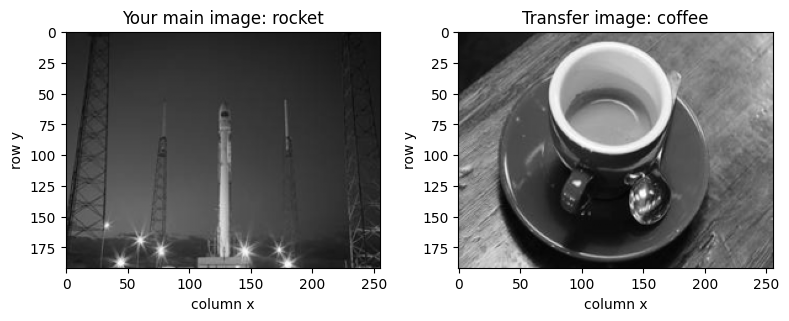

Your required mystery labels: [np.str_('A'), np.str_('D'), np.str_('H'), np.str_('B')]


In [7]:
STUDENT_ID = "230096"  # YOUR TURN: numeric ID, for example "20261234"; integers also work.
STUDENT_ID = str(STUDENT_ID).strip()
if not (STUDENT_ID.isdigit() and 6 <= len(STUDENT_ID) <= 12):
    raise ValueError('Enter your own numeric student ID (6–12 digits), then rerun. Keep leading zeros inside quotes.')
seed=int.from_bytes(hashlib.sha256(STUDENT_ID.encode()).digest()[:8],'big')
rng=np.random.default_rng(seed)
image_names=list(rng.choice(['coffee','chelsea','rocket'],size=2,replace=False))
I=photos[image_names[0]].copy(); TRANSFER=photos[image_names[1]].copy()
noise_level=float(rng.choice([.045,.065,.085])); impulse_level=float(rng.choice([.04,.07,.10]))
G=noise(I,'gaussian',noise_level,seed+1); S=noise(I,'impulse',impulse_level,seed+2)
base=int(rng.integers(10,26)); peak=base+int(rng.choice([45,60,75]));patch=np.full((3,3),base,dtype=float);patch[1,1]=peak
cycles=int(rng.choice([10,14,18]));stripe_axis=str(rng.choice(['x','y'])); width=float(rng.choice([.045,.06,.08]))
edge_high=float(rng.choice([.055,.075,.095]));case=str(rng.choice(['half contrast','stronger noise','rotated image']))
card={'student_id':STUDENT_ID,'images':image_names,'Gaussian_noise_SD':noise_level,'impulse_fraction':impulse_level,'patch_background':base,'patch_center':peak,'Fourier_width':width,'stripe_cycles':cycles,'stripe_axis':stripe_axis,'Canny_high':edge_high,'changed_case':case}
print(json.dumps(card,indent=2));show([I,TRANSFER],['Your main image: '+image_names[0],'Transfer image: '+image_names[1]])

mystery_key=start_mystery(seed)
# Four required suspects per student; the other four are optional investigation.
assigned_labels=list(np.random.default_rng(seed+902).choice(list('ABCDEFGH'),4,replace=False))
yy,xx=np.indices((96,96)); rr=np.random.default_rng(seed+903)
vstep=np.where(xx<48,.2,.8); hstep=np.where(yy<48,.2,.8)
impulse=np.zeros((96,96));impulse[48,48]=1
probes={'constant':np.full((96,96),.5),'vertical step':vstep,'horizontal step':hstep,
        'reversed step':1-vstep,'diagonal step':np.where(xx+yy<96,.2,.8),
        'impulse':impulse,'noisy step':np.clip(vstep+rr.normal(0,.06,(96,96)),0,1),
        'thin line':np.where(np.abs(xx-48)<=1,.8,.2),'photo':I}
print('Your required mystery labels:',assigned_labels)


## 1 · What does a neighbourhood operation actually do? · 3 marks
**Predict first (P1).** Your 3×3 patch contains eight copies of `patch_background` and one `patch_center` (see your card). Calculate its mean and median. Which would preserve a genuine one-pixel bright feature? Which would remove an isolated bright sensor error? Explain why identical pixel values do not reveal which interpretation is correct.

**P2.** For the row `[2,4,6,8]` and asymmetric kernel `[1,2,0]`, write the two valid convolution outputs. Explain the flip, why output is shorter, and why you must read the original input throughout. No summation notation is required.


**Your answer — write before/after running as indicated:**

P1 calculation and two interpretations: The patch is eight 14s and one 74, so the mean is 20.6667 and the median is 14. The median preserves the background when one pixel is an isolated outlier, so it is useful for removing an isolated sensor error. However, if the bright 74 is a genuine one-pixel feature, the median also removes it. The same values do not tell us whether that pixel is a real feature or corruption; the interpretation comes from the image/context.

P2 outputs and reasoning: For [2,4,6,8] and kernel [1,2,0], the valid convolution is [14,20] because convolution flips the kernel to [0,2,1]. The output is shorter because only two complete 3-element overlaps fit in the 4-element input. Each output uses the original input values; the calculation does not overwrite the input between positions. The corresponding valid correlation is [10,16], because correlation does not flip the kernel.


Your patch:
 [[14. 14. 14.]
 [14. 74. 14.]
 [14. 14. 14.]]
Mean: 20.666666666666668 Median: 14.0
Valid convolution: [14 20]
Valid correlation: [10 16]


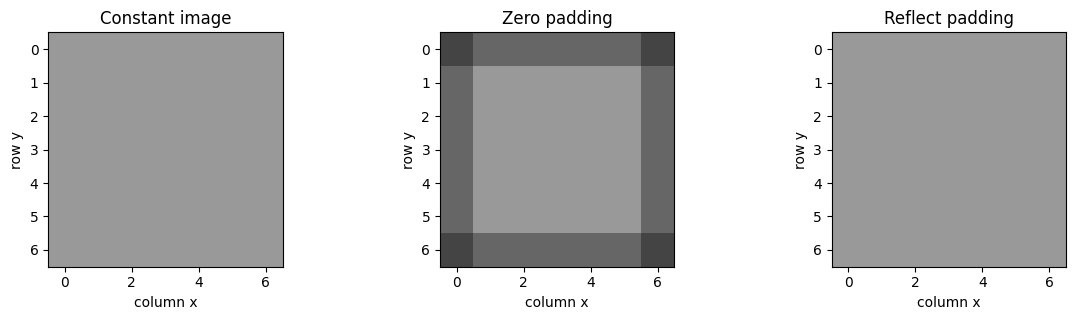

Top-left pixel: 0.26666666666666666 0.6


In [8]:
print('Your patch:\n',patch)
print('Mean:',patch.mean(),'Median:',np.median(patch))
print('Valid convolution:',np.convolve([2,4,6,8],[1,2,0],mode='valid'))
print('Valid correlation:',np.correlate([2,4,6,8],[1,2,0],mode='valid'))
constant=np.full((7,7),.6)
a=ndi.uniform_filter(constant,size=3,mode='constant',cval=0)
b=ndi.uniform_filter(constant,size=3,mode='reflect')
show([constant,a,b],['Constant image','Zero padding','Reflect padding'])
print('Top-left pixel:',a[0,0],b[0,0])


**Q1.** Why does zero padding create a dark border on a perfectly constant image? Is this a real scene boundary? What would the valid output shape be for a 7×7 image and a 3×3 kernel, stride 1?  
**Q2.** Is changing every pixel by `+0.1` a neighbourhood operation? Is a median filter a convolution? Justify both.


**Your answer — write before/after running as indicated:**

Q1: Zero padding inserts zeros outside the image, so pixels near an edge are averaged with values lower than the constant 0.6 image, producing a dark border. That border is an artifact of the padding assumption, not evidence of a real scene boundary. For a 7×7 image and a 3×3 kernel with stride 1, the valid output is 5×5.

Q2: Adding 0.1 to every pixel is a pointwise intensity transformation, not a neighbourhood operation, because each output depends only on its corresponding input pixel. A median filter is not a convolution because it is nonlinear and uses an order statistic rather than a weighted sum.

What I revised after checking P1/P2: I confirmed that the mean is strongly affected by one extreme pixel while the median is not, and that convolution reverses an asymmetric kernel whereas correlation does not.


## 2 · Choose a filter for the corruption and the task · 3 marks
**Predict P3.** Rank mean, Gaussian and median for removing isolated black/white pixels while keeping useful detail. Would your ranking necessarily hold for Gaussian noise? Pick a **specific useful structure** in your main image and record its approximate row/column range.

The clean reference is available only because we simulated noise. The printed mean absolute error (MAE; smaller is better) measures average pixel error; it does **not** directly measure whether your chosen structure survives.


**Your answer — write before/after running as indicated:**

P3 ranking, reason, and protected region: For isolated black/white impulse noise, my ranking is **median > Gaussian > mean**. The median is especially effective because it rejects isolated extremes while preserving a sharp boundary better than averaging. Gaussian noise changes the ranking because averaging filters become more appropriate; in the measured Gaussian-noise trial, bilateral had the lowest MAE, followed by Gaussian, mean, and median. In my main rocket image, I would protect the thin central rocket body and its bright vertical outline, approximately rows 55–185 and columns 120–145.


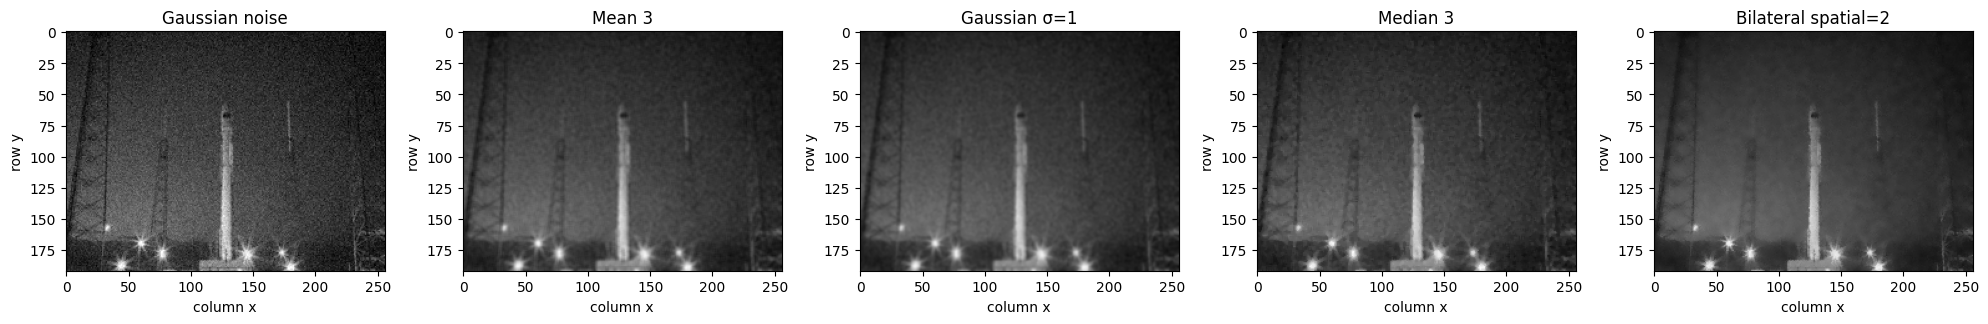

Gaussian noise MAE input: 0.0358
{'mean': 0.0168, 'gaussian': 0.0153, 'median': 0.0187, 'bilateral': 0.013}


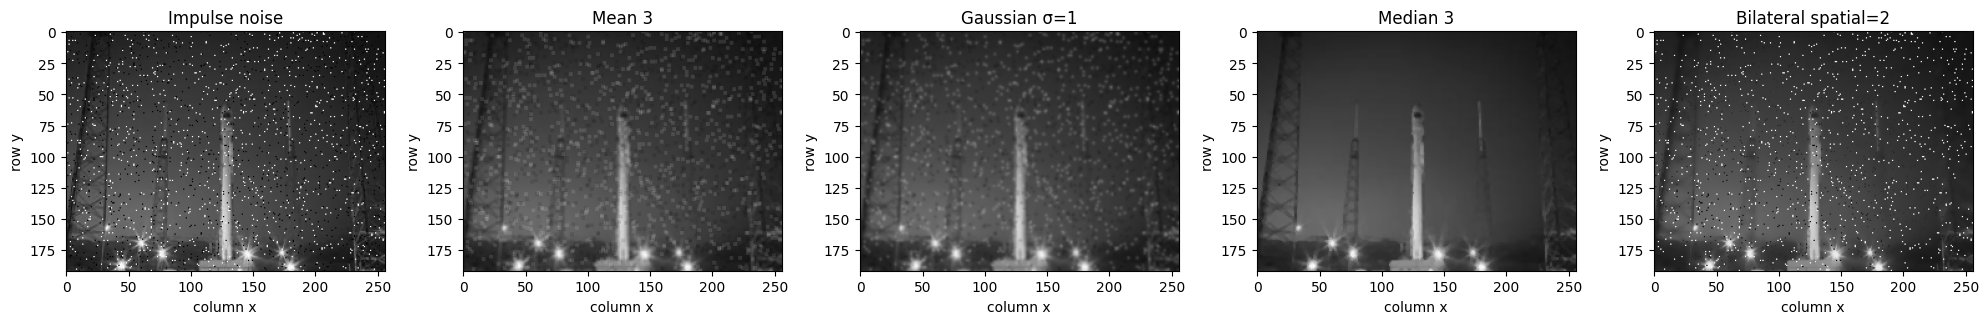

Impulse noise MAE input: 0.0203
{'mean': 0.0253, 'gaussian': 0.0232, 'median': 0.0061, 'bilateral': 0.0261}


In [9]:
for noisy,label in [(G,'Gaussian noise'),(S,'Impulse noise')]:
    results=[apply_filter(noisy,'mean',3),apply_filter(noisy,'gaussian',1),apply_filter(noisy,'median',3),apply_filter(noisy,'bilateral',2)]
    show([noisy]+results,[label,'Mean 3','Gaussian σ=1','Median 3','Bilateral spatial=2'])
    print(label, 'MAE input:',round(quality(noisy,I),4))
    print({name:round(quality(a,I),4) for name,a in zip(['mean','gaussian','median','bilateral'],results)})


### YOUR TURN · One controlled experiment
Choose a filter and compare weak and strong settings on **the same noisy image**. Mean/median use odd window widths 3, 5, 7; Gaussian/bilateral use spatial scales 0.8, 1.5, 3. The supplied example is Gaussian; change it to test your prediction. Do not regenerate noise between trials.


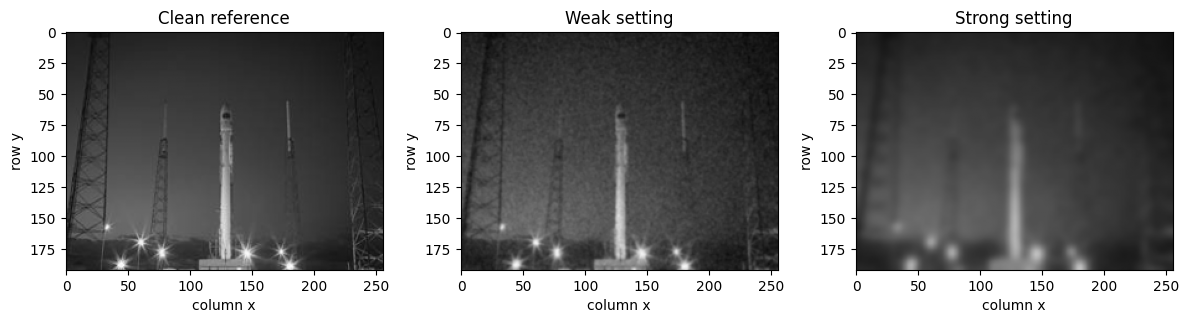

MAE weak/strong: 0.016222355162057115 0.017919678697162555


In [10]:
chosen_filter = 'gaussian'  # YOUR TURN
weak, strong = 0.8, 3.0     # YOUR TURN: use 3,7 for mean/median
selected_noise = G          # YOUR TURN: G or S
weak_result=apply_filter(selected_noise,chosen_filter,weak)
strong_result=apply_filter(selected_noise,chosen_filter,strong)
show([I,weak_result,strong_result],['Clean reference','Weak setting','Strong setting'])
print('MAE weak/strong:',quality(weak_result,I),quality(strong_result,I))


**Your answer — write before/after running as indicated:**

Q3. Which result best serves your named structure? Give settings and two visible observations, including one cost. Answer: The weak Gaussian result (σ=0.8) best serves the thin rocket structure. It preserves the central rocket outline more clearly than σ=3.0, while the strong setting removes more fine detail and makes narrow edges softer. The measured MAE was about 0.0162 for the weak setting versus 0.0179 for the strong setting, so the stronger blur was also worse against the clean reference in this trial.

Q4. Why can bilateral filtering avoid mixing across a strong jump, yet still erase useful small detail? Does it use one fixed kernel everywhere? Answer: Bilateral filtering uses weights that depend on both spatial distance and intensity difference, so pixels across a strong intensity jump receive very small weights and are not mixed as much. It can still erase useful small detail when that detail is close in intensity to its surroundings or is spatially small. It therefore does not use one fixed kernel everywhere; its effective weights depend on the local image values.

Q5. Explain why the lowest MAE and the best result for locating a thin line need not coincide. Answer: MAE averages errors over all pixels, so a thin line occupies only a small fraction of the image. Removing that line may reduce noise over many pixels and improve average MAE while destroying the structure that matters for the task. For locating a thin line, preservation of the line and its continuity is more important than average pixel error alone.


## 3 · Detail is not automatically useful · 2 marks
**Predict P4.** Will sharpening the noisy image remove noise? Will smoothing only across columns affect vertical and horizontal transitions in the same way?


**Your answer — write before/after running as indicated:**

P4: Sharpening does not remove noise; it increases high-frequency content, so it can make noise and halos more visible. The displayed sharpening also produced values outside [0,1] before clipping (about 5.75% of pixels), showing why clipping can hide overshoot. Smoothing only across columns affects vertical transitions more strongly because those boundaries change across columns; horizontal transitions, which mainly change down the rows, are affected less.


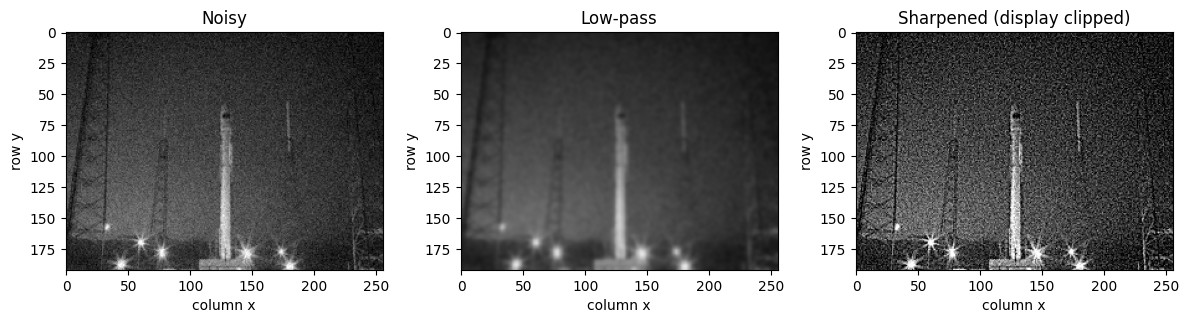

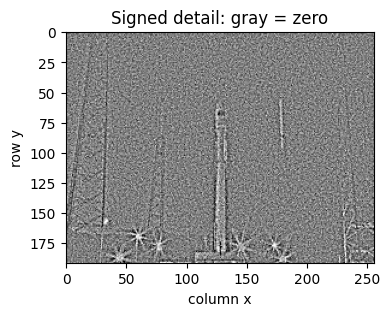

Sharpened fraction outside [0,1]: 0.057474772135416664


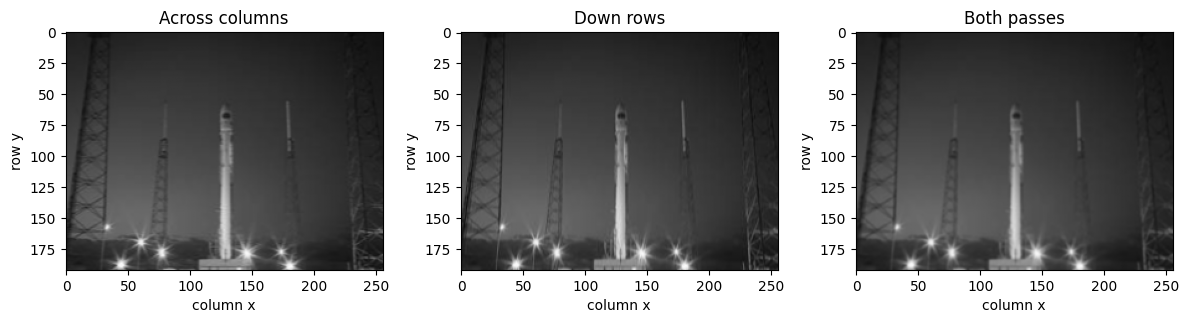

Largest direct/sequential difference: 2.220446049250313e-16


In [11]:
low=apply_filter(G,'gaussian',1.5);detail=G-low; sharp=G+1.5*detail
show([G,low,np.clip(sharp,0,1)],['Noisy','Low-pass','Sharpened (display clipped)'])
show([detail],['Signed detail: gray = zero'],signed=True,vmax=.2)
print('Sharpened fraction outside [0,1]:',np.mean((sharp<0)|(sharp>1)))
k=np.array([1,2,1],dtype=float)/4
horizontal=ndi.correlate1d(I,k,axis=1,mode='reflect')
vertical=ndi.correlate1d(I,k,axis=0,mode='reflect')
sequential=ndi.correlate1d(horizontal,k,axis=0,mode='reflect')
direct=ndi.correlate(I,np.outer(k,k),mode='reflect')
show([horizontal,vertical,sequential],['Across columns','Down rows','Both passes'])
print('Largest direct/sequential difference:',np.max(np.abs(direct-sequential)))


**Your answer — write before/after running as indicated:**

Q6. Give one noise/halo example in the sharpening output. Is the signed detail image itself a sharpened photograph? Answer: A visible example is a bright/dark halo around strong rocket edges or bright lights after sharpening; small noise fluctuations can also become more prominent. The signed detail image is not a sharpened photograph: it is the residual high-frequency component, with positive and negative values around zero.

Q7. Why do two 1D passes match the direct 2D result here? For a 9×9 separable kernel, compare weighted terms per pixel. Does this guarantee the same runtime ratio? Answer: Two 1D passes match the direct 2D result because the 2D kernel is separable: outer([1,2,1]/4,[1,2,1]/4) gives the same weights as applying the horizontal and vertical 1D filters successively. A 9×9 direct kernel has 81 weighted terms per pixel, while two 1D passes use 9+9 = 18 terms per pixel, ignoring implementation overhead. This does not guarantee an exact runtime ratio because memory access, boundaries, vectorization, and library optimizations also affect runtime.

Q8. Would applying x- then y-derivatives in sequence similarly give gradient magnitude? Explain your expectation; revisit in Part 5. Answer: No. Applying an x-derivative and then a y-derivative produces a mixed second derivative, not the gradient magnitude sqrt(Gx²+Gy²). It can cancel or behave differently on edges, whereas gradient magnitude combines the two directional strengths without signed cancellation.


## 4 · Fourier filtering as a practical tool · 3 marks
**No Fourier mathematics is assessed.** Think of a mask as a set of controls: keep or suppress patterns that vary at different speeds. In a **shifted spectrum**, the centre is slow/zero frequency, not the physical centre of an object. Distance from the centre indicates faster variation. A larger low-pass width lets more fine variation through.

**Predict P5.** Which removes more fine detail: half your assigned `width` or twice it? Does “high frequency” mean “noise”? Name one useful high-frequency structure in your image.


**Your answer — write before/after running as indicated:**

P5: Twice the assigned width (0.16) removes less fine detail because a wider low-pass mask keeps more frequencies. Half the width (0.04) is more aggressive and removes more fine variation. High frequency does not automatically mean noise: useful thin boundaries, fine lettering, or narrow structures can also contain high-frequency content. In the rocket image, the thin rocket outline and bright star-like lights are useful high-frequency structures.


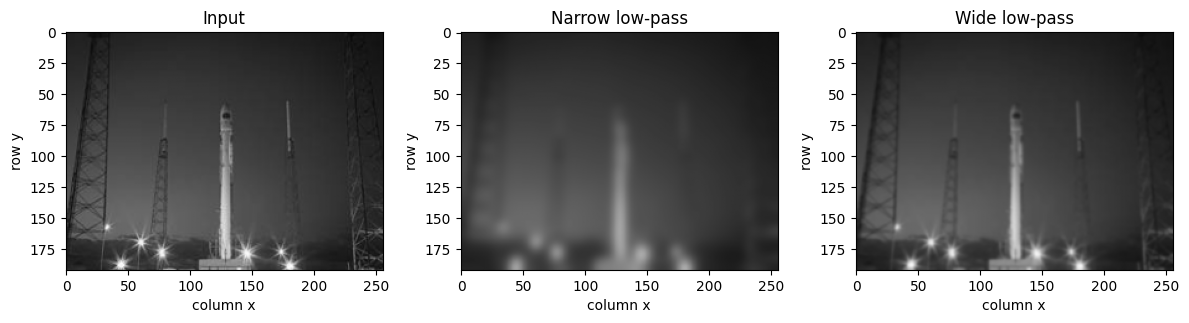

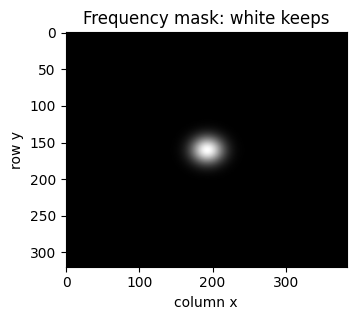

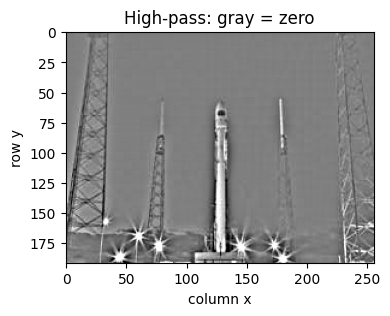

Low + high reconstruction error: 3.677613769070831e-16


In [12]:
lp1,mask=frequency_filter(I,width=width/2)
lp2,_=frequency_filter(I,width=width*2)
hp,_=frequency_filter(I,width=width/2,mode='high')
show([I,lp1,lp2],['Input','Narrow low-pass','Wide low-pass'])
show([mask],['Frequency mask: white keeps'])
show([hp],['High-pass: gray = zero'],signed=True,vmax=.2)
print('Low + high reconstruction error:',np.max(np.abs(I-lp1-hp)))


### Use, compare, and challenge the result
The next cell compares ideal, Butterworth and Gaussian masks at the same named width. Their transitions differ, so **equal width does not mean equal smoothing strength**. A sharp cutoff may cause ripples near a sharp step. The line plot shows overshoot that clipping could conceal.


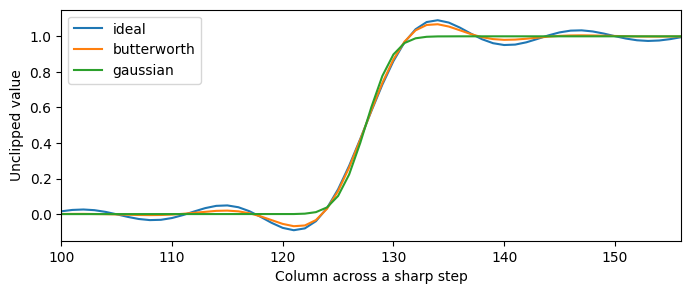

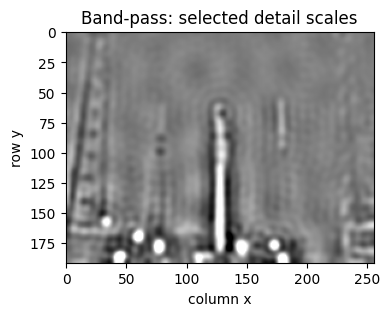

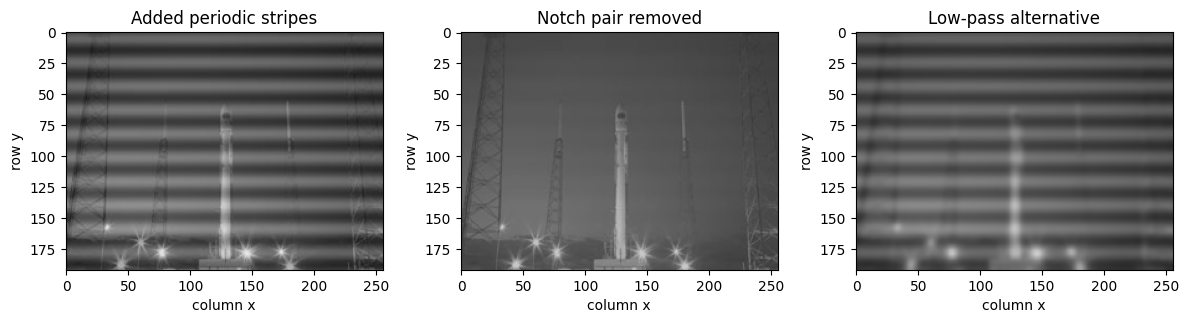

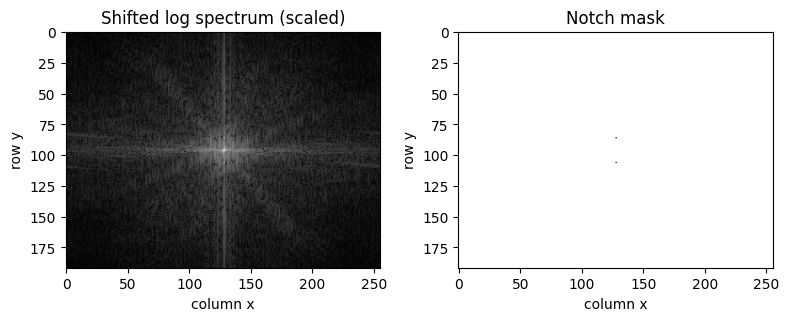

MAE notch/low-pass: 0.0024155180838190825 0.06385458593854525


In [13]:
step=np.zeros((128,256));step[:,128:]=1
fig,ax=plt.subplots(figsize=(8,3))
for family in ['ideal','butterworth','gaussian']:
    result,_=frequency_filter(step,width=width,family=family)
    ax.plot(result[64],label=family)
ax.set_xlim(100,156);ax.set_xlabel('Column across a sharp step');ax.set_ylabel('Unclipped value');ax.legend();plt.show()
band,_=frequency_filter(I,width=.03,outer=.12,mode='band')
show([band],['Band-pass: selected detail scales'],signed=True,vmax=.2)
# A controlled periodic disturbance: added without clipping to preserve its known frequency.
y,x=np.indices(I.shape);coordinate=x/I.shape[1] if stripe_axis=='x' else y/I.shape[0]
striped=.2+.6*I+.12*np.sin(2*np.pi*cycles*coordinate)
clean_periodic=.2+.6*I
notched,notchmask=remove_periodic(striped,cycles,stripe_axis)
blurred,_=frequency_filter(striped,width=width)
sp=spectrum(striped)
show([striped,notched,blurred],['Added periodic stripes','Notch pair removed','Low-pass alternative'])
show([sp/sp.max(),notchmask],['Shifted log spectrum (scaled)','Notch mask'])
print('MAE notch/low-pass:',quality(notched,clean_periodic),quality(blurred,clean_periodic))


### YOUR TURN · Make a wrong choice deliberately
Change `wrong_cycles` to a value different from your assignment. Run the same notch tool and inspect the remaining stripes. This is a controlled synthetic case: in real images the interference frequency must first be estimated, and a removed frequency may also contain real image detail.

**Optional mystery (5 minutes):** A photo develops regular stripes. A colleague says “blur until they disappear.” Before seeing the output, propose a more selective tool, explain which pattern in the spectrum supports it, and predict what happens when the rejected frequency is wrong. Your answer: …


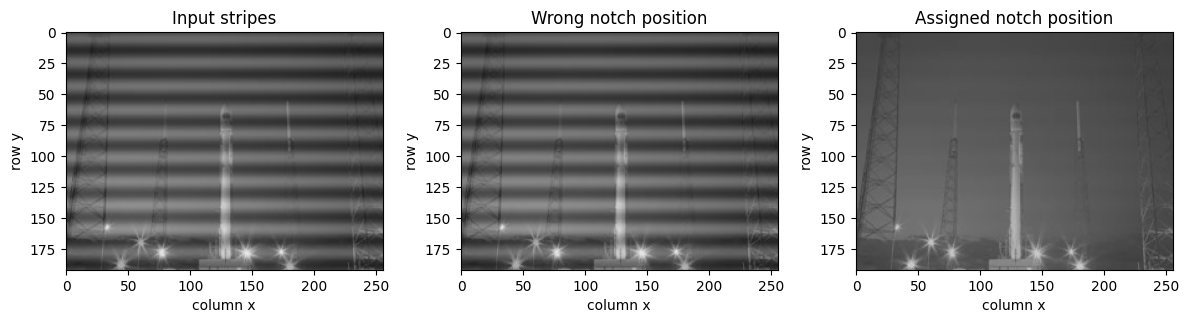

In [18]:
wrong_cycles = cycles + 10  # YOUR TURN: test a different wrong value too
wrong,_=remove_periodic(striped,wrong_cycles,stripe_axis)
show([striped,wrong,notched],['Input stripes','Wrong notch position','Assigned notch position'])


**Your answer — write before/after running as indicated:**

Q9. Explain low-pass, high-pass, band-pass and notch in plain language, using one result each. Answer: A low-pass filter keeps slow intensity variation and suppresses fine detail; the narrow low-pass result is an example. A high-pass filter suppresses slow variation and keeps fine changes; the high-pass result shows signed detail around zero. A band-pass keeps only a selected range of spatial frequencies; the band-pass image emphasizes selected detail scales. A notch filter removes very specific frequencies; the correct notch removes the periodic stripes while preserving much more of the clean image.

Q10. Where did you see ringing? Why is an abrupt cutoff not always the best filter? Answer: Ringing appeared around the sharp step in the ideal-cutoff result. An abrupt frequency cutoff creates oscillatory sidelobes in the spatial response, so a sharp cutoff can introduce overshoot and undershoot near edges. Smoother Gaussian or Butterworth transitions reduce this artifact.

Q11. Why did the wrong notch fail? Why might the correct notch still remove real structure? Are the bright spectrum spots object locations? Answer: The wrong notch failed because the removed FFT bins did not match the actual stripe frequency (10 cycles along the y direction). The correct notch can still remove real structure if genuine image content shares those same frequency bins. The bright spots in a shifted spectrum represent spatial frequencies and orientations, not physical object locations.

Q12. Can a high-pass result be submitted directly as a binary object-boundary map? Why? Answer: No. A high-pass result is a continuous signed response, not a binary boundary map. It contains both positive and negative responses and also responds to texture/noise, so a thresholding and edge-decision process is still needed.


## 5 · Case file: eight filters, missing labels · 3 marks
**Do this before opening the helper implementation.** Each student has a different label mapping. Your A may not be your friend's A. Work on the **four labels printed on your assignment card**; investigate all eight only as an optional extension.

Possible identities (each used once): **Sobel x, Sobel y, Prewitt magnitude, Scharr magnitude, Roberts magnitude, Laplacian, Laplacian of Gaussian (LoG), Difference of Gaussians (DoG)**. DoG is an extension: it subtracts a strongly blurred image from a less blurred image, emphasizing a range of detail scales. DoG and LoG can look similar; they are not numerically identical here.

### Mission 1 · Design a test before seeing its answer
Available probes: `constant`, `vertical step`, `horizontal step`, `reversed step`, `diagonal step`, `impulse`, `noisy step`, `thin line`, `photo`.

Choose probes deliberately. A complex photograph can hide differences that a simple pattern reveals. At least one test must try to **disprove** your preferred identity.

For each assigned label:
1. Predict its response to two different probes before running them.
2. Observe whether the output is signed, direction-selective, sensitive to noise, or spread over a wider region.
3. Record two candidate identities and choose a third test that separates them.
4. If they still cannot be distinguished, explain the ambiguity and request a kernel clue. Correctly admitting insufficient evidence is better than guessing.

All signed displays use gray=zero and the same range. A brighter output does not prove a better detector; Roberts also has different scaling and a 2×2 footprint.


**Investigation log — copy one row per assigned label; fill predictions before testing.**

| Label | Probe 1 + prediction | Probe 2 + prediction | Actual observations | Two candidates | Discriminating test + result | Final identity + confidence |
|---|---|---|---|---|---|---|
| A | Vertical step: predict a strong, nonnegative edge response. | Horizontal step: predict a similar nonnegative response because it is a magnitude. | Both steps gave max ≈0.30; impulse response was localized and max ≈0.312. | Prewitt magnitude / Scharr magnitude | Impulse test: A reached ≈0.312, higher than the Prewitt response ≈0.236. | **Scharr magnitude — high confidence** |
| D | Vertical step: predict nonnegative edge response. | Horizontal step: predict similar magnitude. | Both gave max ≈0.30; impulse max ≈0.236. | Prewitt magnitude / Scharr magnitude | Impulse test separated it from A/Scharr: lower peak ≈0.236. | **Prewitt magnitude — high confidence** |
| H | Vertical step: predict almost zero because this derivative measures y-direction change. | Horizontal step: predict a strong signed response. | Vertical step was zero; horizontal step reached about +0.30. | Sobel x / Sobel y | Repeat vertical step: zero response confirms the y derivative. | **Sobel y — high confidence** |
| B | Thin line: predict a spread, signed second-derivative response. | Noisy step: predict smoothing before the second derivative, so less noise sensitivity than a raw Laplacian. | Thin line produced broad positive/negative lobes (about -0.124 to +0.058); noisy step was also signed and smoothed. | LoG / Laplacian | Compare impulse/noisy response with a raw Laplacian: LoG is spatially smoother and less sensitive to pixel-scale noise. | **LoG — high confidence** |


Name one result that would contradict your favourite hypothesis: If A or D produced a strongly signed directional response, that would contradict the magnitude-filter hypotheses. If H responded strongly to a vertical step, that would contradict Sobel y. If B behaved like an unsmoothed noisy second derivative, that would contradict LoG.


--- A: impulse ---


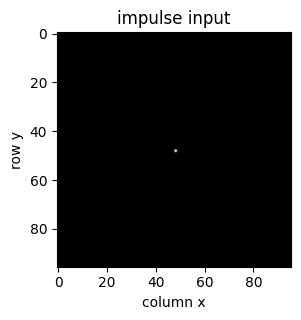

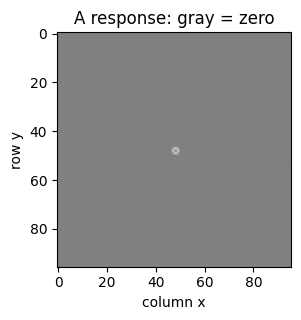

Interior min/max: 0.0 0.3125
Mean absolute interior response: 0.00028


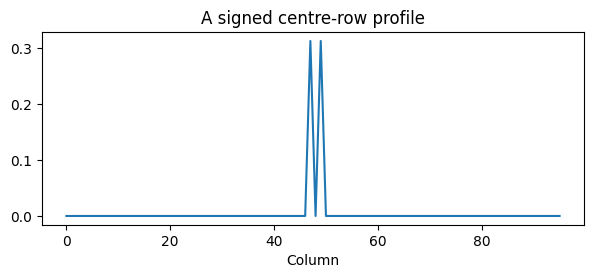

--- D: impulse ---


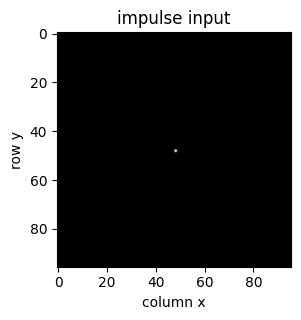

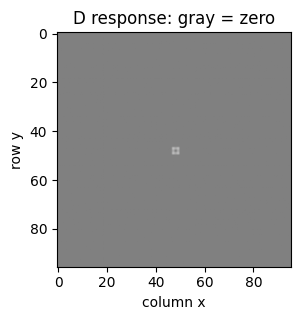

Interior min/max: 0.0 0.2357
Mean absolute interior response: 0.00025


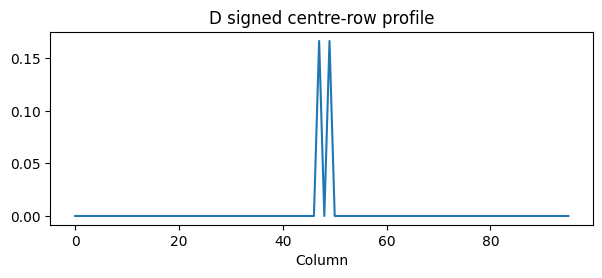

--- H: vertical step ---


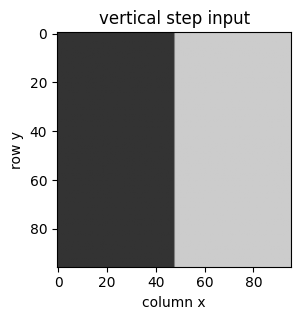

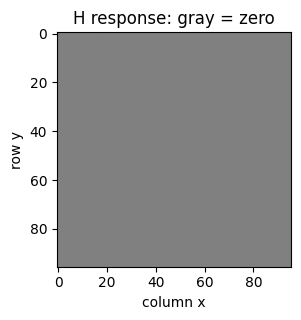

Interior min/max: -0.0 0.0
Mean absolute interior response: 0.0


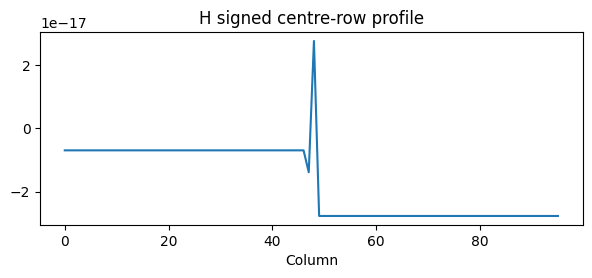

--- B: thin line ---


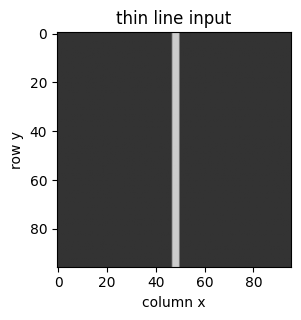

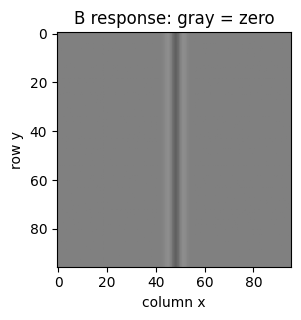

Interior min/max: -0.12437 0.05824
Mean absolute interior response: 0.0069


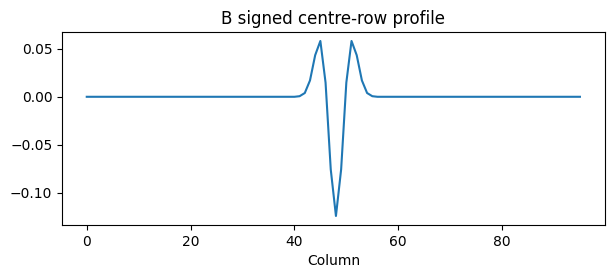

In [25]:
# YOUR TURN: change only the label and the probe name; rerun for your planned tests.
for label, probe in [('A','impulse'), ('D','impulse'), ('H','vertical step'), ('B','thin line')]:
    print(f'--- {label}: {probe} ---')
    probe_mystery(label, probe)


### Mission 2 · Request a clue only when you can say why you need it
**Before running:** explain why your current evidence cannot distinguish two candidates. Then inspect the numerical weights or processing steps. For Prewitt and Scharr, compare the relative middle-row weights and the normalized responses rather than raw brightness. No kernel implementation or lengthy calculation is needed.

My two candidates, ambiguity, and information needed: A and D initially looked ambiguous because both were nonnegative gradient magnitudes and responded similarly to clean vertical and horizontal steps. I needed a test sensitive to their kernel weights rather than just orientation. The impulse probe provided that evidence: A had a larger peak (about 0.312) while D peaked around 0.236. The kernel clue would also distinguish them through the stronger Scharr middle-row weights versus the uniform Prewitt derivative weights.


In [ ]:
# Optional clue: uncomment after writing your reason.
# kernel_clue(label)


### Mission 3 · Submit a supported hypothesis
The checker does not award marks and is not a secure test. Use it after completing your evidence log, not to try every name. Record a correction if needed; retain your original reasoning.


In [26]:
guess = 'Scharr magnitude'     # YOUR TURN: one candidate name exactly as listed above
my_evidence = 'A is nonnegative and responds equally to vertical and horizontal steps; its impulse response peaked at about 0.312, while the Prewitt candidate peaked at about 0.236, so the stronger Scharr weighting is supported.'  # YOUR TURN: summarize two specific observations and an excluded alternative
if guess:
    check_identity(label,guess,my_evidence)
else:
    print('Complete your investigation log, then enter your hypothesis.')


Not yet. Choose a probe that separates your guess from an alternative.


### Mission 4 · The faulty crack detector
A colleague combined two derivatives and reports: “Some diagonal cracks have disappeared, although the vertical ones are strong.” Three pipelines are supplied below. The image contains a diagonal intensity boundary as a controlled stand-in for one side of a crack.

**Predict before running:** which mistake could erase a strong diagonal response? What would a pure vertical-boundary test miss?

Possible diagnoses: **using only Gx**, **adding signed Gx and Gy**, or **combining their strengths with magnitude**. Identify P, Q and R from evidence. Then explain why running x-derivative followed by y-derivative is not a valid replacement for magnitude.

Prediction and discriminating test: I predict that adding signed Gx and Gy can cancel on a diagonal boundary when the two components have opposite signs. A pure vertical-boundary test could miss this because one derivative dominates there and the cancellation pattern is not exposed. The controlled diagonal scene is therefore the discriminating test.


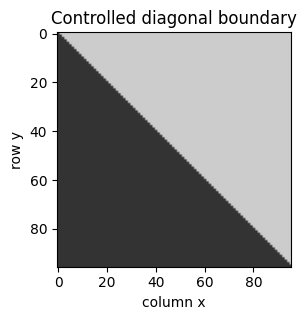

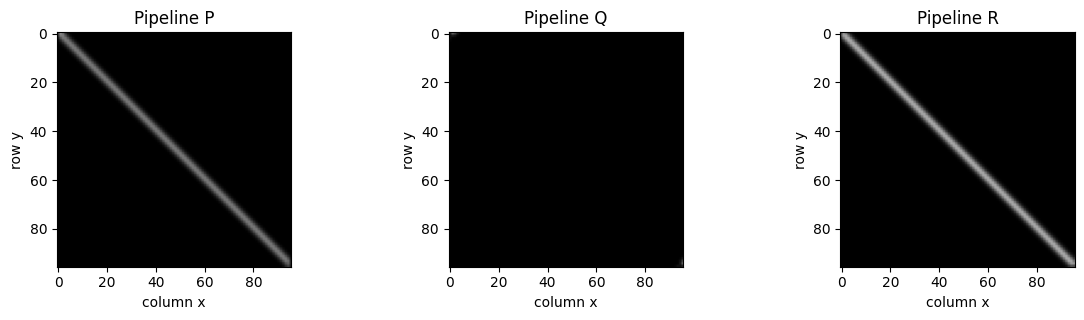

Mean response near the diagonal (interior only):
P 0.10301
Q 0.0
R 0.14568


In [27]:
fault_scene=np.where(xx-yy>0,.8,.2)
fx,fy,fm=gradients(fault_scene,sigma=1)
fault_names=['one component','signed sum','magnitude']
fault_order=np.random.default_rng(seed+904).permutation(3)
fault_arrays=[np.abs(fx),np.abs(fx+fy),fm]
show([fault_scene],['Controlled diagonal boundary'])
show([fault_arrays[j] for j in fault_order],['Pipeline P','Pipeline Q','Pipeline R'],vmax=.3)
print('Mean response near the diagonal (interior only):')
region=(np.abs(xx-yy)<=2)&(xx>8)&(xx<87)&(yy>8)&(yy<87)
for label_f,j in zip('PQR',fault_order):print(label_f,round(float(fault_arrays[j][region].mean()),5))


**Diagnosis:** P = one component (|Gx|); Q = signed sum (Gx + Gy); R = magnitude  
**Evidence for the cancellation failure:** Q had mean response **0.0** near the diagonal, while P was about **0.103** and R about **0.146**. The signed components cancel instead of reinforcing each other.
**A one-line repair in words:** Combine the two derivative strengths with the Euclidean magnitude `sqrt(Gx² + Gy²)` instead of adding signed values.  
**Why stronger responses alone do not establish better crack detection:** A stronger response can come from scaling, noise, or an easy orientation and does not prove that the detector preserves the target while rejecting distractors.

### Direction and second-derivative checkpoint
- Which of your probes separates Sobel x from Sobel y? Explain measurement direction versus boundary orientation.
- Why does reversing contrast reverse a signed derivative but not its magnitude?
- Why is a Laplacian response different from a gradient vector? What information disappears if only its absolute value is displayed?
- Compare a raw Laplacian and a smoothed second-derivative response on `noisy step` and `thin line`. What is gained and lost? Use a clue if neither is among your four assigned labels; alternatively explain your prediction without executing extra tests.

Your explanations:
- A vertical step separates Sobel x from Sobel y: Sobel x responds strongly to the vertical boundary because intensity changes across columns; Sobel y responds to horizontal boundaries because intensity changes down rows.
- Reversing contrast reverses a signed derivative because the intensity difference changes sign, but its magnitude stays the same because absolute strength is unchanged.
- A Laplacian is a scalar second-derivative response rather than a gradient vector, so it does not retain a directional vector. Displaying only its absolute value also loses the sign, which distinguishes positive and negative second-derivative regions.
- A raw Laplacian reacts strongly to pixel-scale noise and produces a sharper response, while LoG first smooths and therefore suppresses some noise but spreads/softens the second-derivative response. For a noisy step the LoG is more stable; for a thin line the smoothing can reduce or broaden the finest details.

**Part 5 marking:** 1.5 marks for probe design, evidence and revisions; 0.75 for supported identities (including sensible handling of ambiguity); 0.75 for the faulty-pipeline diagnosis and direction/brightness checkpoint. Unexplained correct names are insufficient.


### YOUR TURN · Test a brightness claim
Without clipping, compare `I`, `I + 0.2`, and `0.5 * I` using the same Sobel operator. **Predict first:** which transformation leaves gradients unchanged? Which changes the number of pixels passing a fixed threshold?


**Your answer — write before/after running as indicated:**

P7 brightness prediction: Adding a constant offset should leave Sobel gradients unchanged if there is no clipping, because derivatives of a constant are zero. Multiplying the image by 0.5 should halve every gradient magnitude. Therefore the fixed 0.05 threshold should select fewer pixels after the 0.5 scaling.


Offset maximum magnitude difference: 1.249000902703301e-16
Half-scale maximum difference from 0.5*original: 0.0
Fraction above threshold, original / +0.2 / 0.5x: 0.0767822265625 0.0767822265625 0.025716145833333332


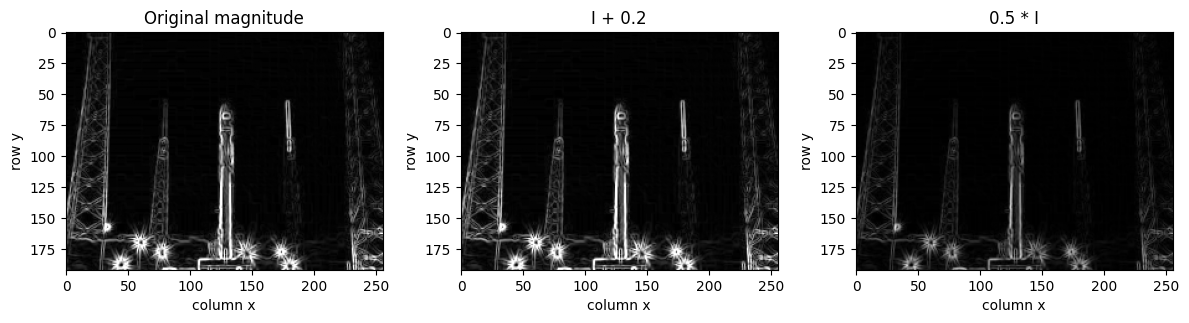

In [28]:
_,_,original_m=gradients(I)
_,_,offset_m=gradients(I+0.2)
_,_,half_m=gradients(0.5*I)
print('Offset maximum magnitude difference:',np.max(np.abs(offset_m-original_m)))
print('Half-scale maximum difference from 0.5*original:',np.max(np.abs(half_m-0.5*original_m)))
print('Fraction above threshold, original / +0.2 / 0.5x:',
      np.mean(original_m>=.05),np.mean(offset_m>=.05),np.mean(half_m>=.05))
show([original_m,offset_m,half_m],['Original magnitude','I + 0.2','0.5 * I'],vmax=.15)

**Brightness checkpoint — report both trials:**

Which transformation left the gradient unchanged, and under which assumptions? Adding +0.2 left the gradient unchanged; the measured maximum difference was about 1.25×10⁻¹⁶, effectively zero. This holds when the addition does not cause clipping and the same linear filtering/derivative operation is used.

Which changed the fraction above a fixed threshold? Give your observed values. Multiplying by 0.5 changed the fraction above 0.05 from **0.07678** to **0.02572** because all gradient magnitudes were halved.

Would the offset conclusion necessarily hold after clipping or under a shadow? Would the offset conclusion necessarily hold after clipping or under a shadow? No. Clipping is nonlinear and can create/erase edges, and a shadow is a spatially varying intensity change rather than a constant offset, so it can create a gradient.

Identify one edge in your photograph that may not be an object boundary. Identify one edge in your photograph that may not be an object boundary. A bright highlight/reflection on the rocket or a star-like lamp flare can create an edge response without representing the true object silhouette.


## 6 · From a response to an edge decision · 3 marks
We use a supplied **teaching Canny** implementation: smoothing → Sobel gradients → four-direction non-maximum suppression → 8-connected hysteresis. It is a simplified teaching detector, not a reproduction of every detail in OpenCV. Thresholds use normalized Sobel magnitude, **not OpenCV's 0–255 units**.

**Predict P8.** What happens if both thresholds increase while smoothing stays fixed? Why might fewer edge pixels mean a worse result?

**Before running:** on the toy map below, mark all entries that survive low=4 and high=8. Diagonal connections count. Then explain what happens if the middle connected `6` becomes `3`.
```
10 0 0 0 6
 0 6 0 0 0
 0 0 6 0 0
 0 0 0 0 0
```
Across one ridge `[0,2,7,4,1]`, which value should thinning retain? In which direction should neighbours be compared?


**Your answer — write before/after running as indicated:**

P8 and toy-map answers (including changed middle value): Raising both Canny thresholds while keeping smoothing fixed produces fewer accepted edge pixels because fewer pixels are strong enough to start or support hysteresis. Fewer edges can be worse if a low-contrast but meaningful boundary falls below the new thresholds.

For the toy map, the strong pixel is 10 at the top-left. The three diagonal 6s form a connected low-threshold chain, so they survive hysteresis because they connect to the strong 10. The isolated 6 at the top-right does not connect to a strong pixel and is removed. If the middle connected 6 becomes 3, the connection from 10 to the lower 6 is broken, so the lower 6 is removed too.

For the ridge [0,2,7,4,1], thinning should retain the central maximum **7**. Neighbours must be compared along the direction perpendicular to the edge/ridge, which is the local gradient direction; in this 1D example that means comparing 7 with 2 and 4.


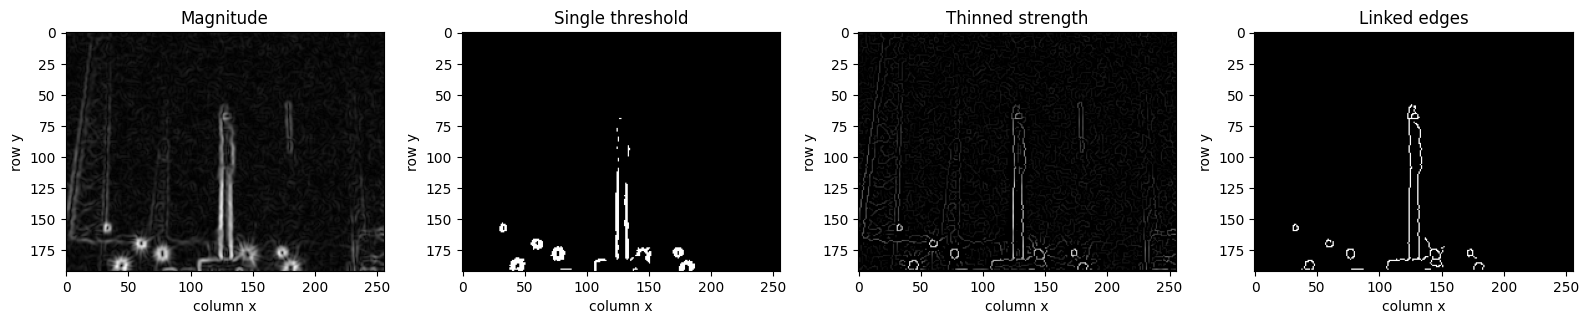

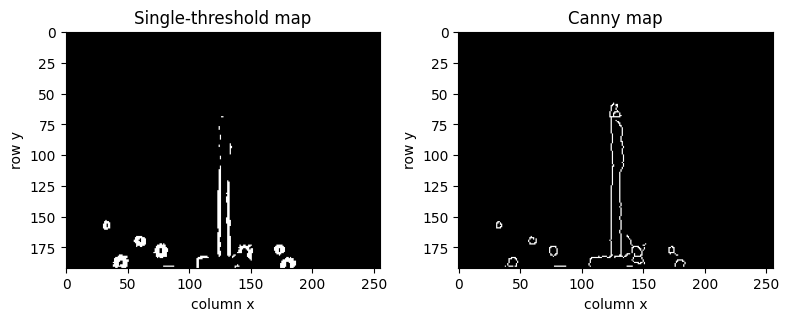

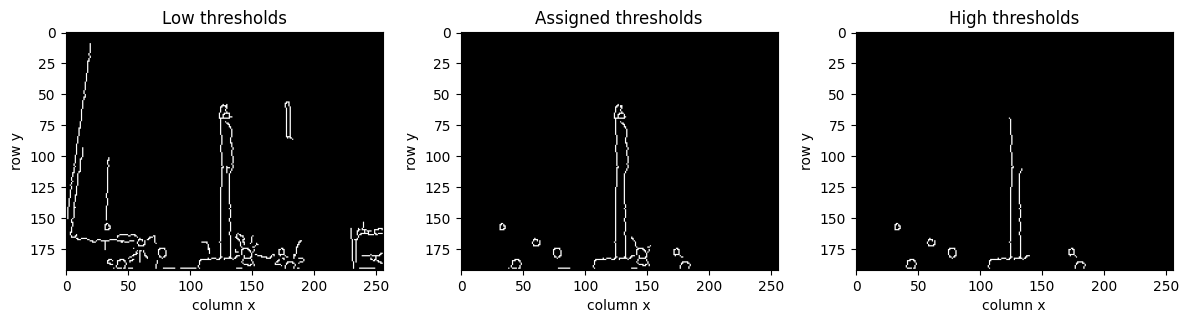

Edge fractions (NOT accuracy): [0.027, 0.0105, 0.0072]


In [29]:
m,nms,edges=canny_steps(G,sigma=1.2,low=edge_high*.4,high=edge_high)
show([m,m>=edge_high,nms,edges],['Magnitude','Single threshold','Thinned strength','Linked edges'],vmax=.15)
# Boolean maps are shown separately at their proper 0–1 scale.
show([m>=edge_high,edges],['Single-threshold map','Canny map'])
trial_edges=[]
for factor in [.6,1,1.6]:
    _,_,e=canny_steps(G,sigma=1.2,low=edge_high*.4*factor,high=edge_high*factor)
    trial_edges.append(e)
show(trial_edges,['Low thresholds','Assigned thresholds','High thresholds'])
print('Edge fractions (NOT accuracy):',[round(float(e.mean()),4) for e in trial_edges])


### YOUR TURN · Change only the smoothing scale
Keep the thresholds fixed. Run sigma=0.6 and sigma=3.0. Choose a useful outline and check **both** missing pieces and unwanted detections.


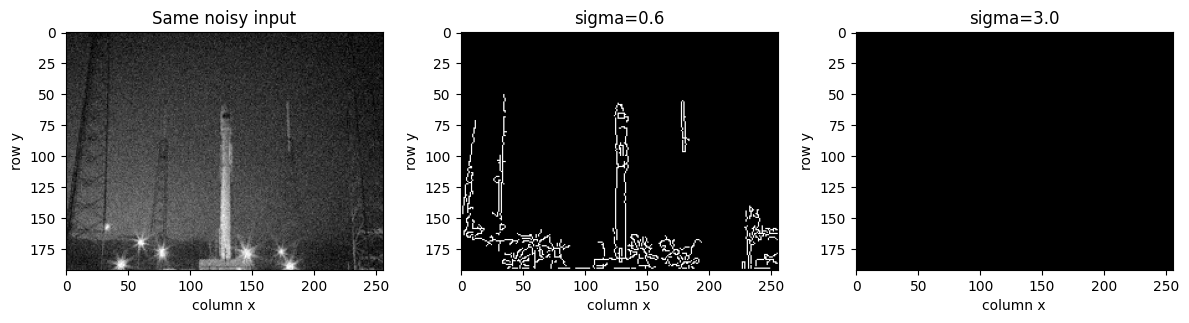

Edge fractions sigma=0.6 / 3.0: [0.0405, 0.0]


In [31]:
trial_edges=[]
for test_sigma in [0.6,3.0]:
    _,_,e=canny_steps(G,sigma=test_sigma,low=edge_high*.4,high=edge_high)
    trial_edges.append(e)
show([G,trial_edges[0],trial_edges[1]],['Same noisy input','sigma=0.6','sigma=3.0'])
print('Edge fractions sigma=0.6 / 3.0:',[round(float(e.mean()),4) for e in trial_edges])


**Your answer — write before/after running as indicated:**

Q17. Identify a missing useful boundary and an unwanted edge, with locations. Compare threshold and sigma trials; state the best tested settings for your goal and one remaining failure.
Answer: A useful boundary is the bright outline of the central rocket body, especially around rows 55–185 and columns 120–145. An unwanted edge is a fine texture/noise response in the dark sky or around the lattice structures. With the fixed thresholds, σ=0.6 produced many more detections (about 0.0405 of pixels), while σ=3.0 was so strong that the tested edge map was essentially empty. The best tested setting for preserving the rocket outline while suppressing noise was around σ=1.2; σ=0.6 retained more detail but also more unwanted texture, while σ=3.0 removed useful boundaries. A remaining failure is that weak/high-contrast highlights can still be confused with object edges.

Q18. Explain what thinning and hysteresis each add beyond a single threshold. Can linking also preserve unwanted texture?
Answer: Thinning keeps only local maxima across the gradient direction, turning thick responses into narrow candidate boundaries. Hysteresis then keeps weak pixels only when they are connected to strong edges, which removes many isolated weak responses. Linking can also preserve unwanted texture if that texture forms a connected path to a strong edge.


## 7 · Independent transfer: defend a decision · 3 marks
Your **second image** and the printed **changed case** are the test. Choose a meaningful target structure on this new image (e.g., a rocket silhouette, cup rim, or animal outline). Describe which visible changes should count as correct and which are distractors.

**Before running P9:** choose smoothing and thresholds using your earlier experiments. Predict the failure caused by your assigned change. Do not change the case or image to get an easier outcome.

The test code supplies a baseline and changed image. First keep parameters fixed; only then change **one** setting to address your predicted failure. For rotation, remember that row/column locations rotate too.


**Your answer — write before/after running as indicated:**

Target structure and distractors: The target is the **rim and outer silhouette of the coffee cup**, especially the elliptical upper rim and the cup's outer boundary. Distractors include coffee-surface texture, saucer reflections/highlights, and small texture on the table.

P9 frozen settings, expected failure, and why: …


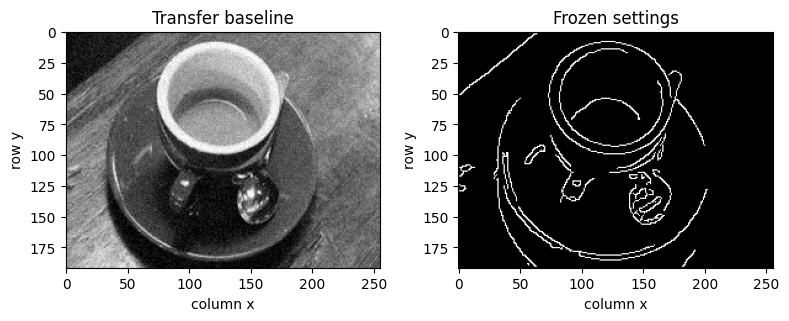

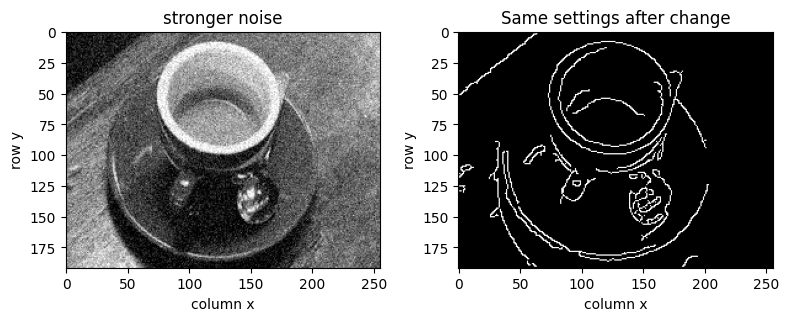

In [33]:
baseline=noise(TRANSFER,'gaussian',noise_level,seed+30)
if case=='half contrast': changed=.25+.5*baseline
elif case=='stronger noise': changed=noise(TRANSFER,'gaussian',noise_level*2,seed+30)
else: changed=np.rot90(baseline)
final_sigma = 1.2          # YOUR TURN
final_low = edge_high*.4   # YOUR TURN
final_high = edge_high    # YOUR TURN
_,_,before=canny_steps(baseline,final_sigma,final_low,final_high)
_,_,after=canny_steps(changed,final_sigma,final_low,final_high)
show([baseline,before],['Transfer baseline','Frozen settings'])
show([changed,after],[case,'Same settings after change'])


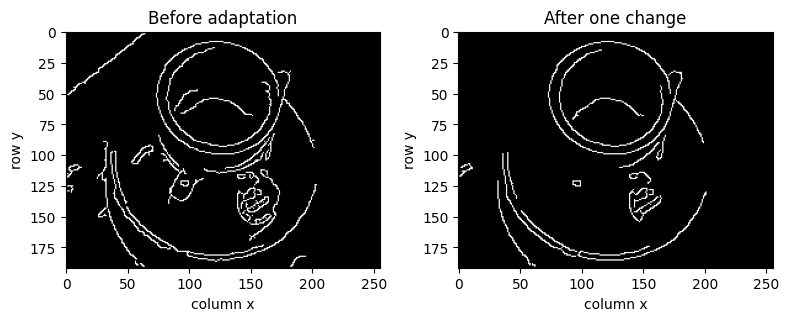

In [34]:
# YOUR TURN: change exactly ONE parameter below, then rerun.
adapted_sigma = 1.6
adapted_low = final_low
adapted_high = final_high
_,_,adapted=canny_steps(changed,adapted_sigma,adapted_low,adapted_high)
show([after,adapted],['Before adaptation','After one change'])


**Your answer — write before/after running as indicated:**

Q19. Record the single changed setting, one improvement and one cost, with specific regions. If it failed, explain why and propose a next test.
Answer: I changed one setting: smoothing sigma from 1.2 to 1.6, keeping both thresholds fixed. The improvement was fewer noise/texture detections around the saucer and table while the main cup outline remained detectable. The cost was loss of some fine/high-contrast detail, such as small highlights and parts of the cup/saucer texture. If the result were still too noisy, my next test would increase sigma only slightly again or raise the high threshold, but I would check carefully for missed parts of the cup rim.

Q20. How would you assess missed and false boundaries using a small manually marked reference? State a pixel tolerance and explain why image-wide edge count is insufficient. How would you separate parameter tuning images from final evaluation images?
Answer: I would manually mark the reference boundaries and count a detected pixel as correct if it falls within a small tolerance, for example 2 pixels, of a reference boundary. I would report missed reference pixels/segments and false detected pixels/segments separately. Image-wide edge count is insufficient because many extra texture edges can compensate numerically for missed important boundaries. Parameter tuning should use a training/tuning set of images; final evaluation should use separate images that were not used to choose sigma or thresholds.


### Exit questions · Answer without running more code
1. A student says “remove all high frequencies to keep only objects.” Give a counterexample.
2. A filter improves average pixel error but deletes a narrow crack. Should it be used for crack inspection? What evidence decides?
3. Your edge map includes a shadow and misses a low-contrast silhouette. Does Canny know which is an object? Explain.
4. In 3–4 sentences, explain one prediction you changed and the observation that changed it.


**Your answer — write before/after running as indicated:**

Exit 1: Removing all high frequencies would also remove useful narrow structures such as thin object boundaries, small letters, cracks, and fine texture. Therefore low-pass filtering cannot be assumed to keep only objects.


Exit 2: It should not automatically be used for crack inspection. A crack can occupy very few pixels, so average error may improve while the crack disappears. The decision should be based on crack detection rate, continuity/width preservation, and false/missed crack measurements on representative reference images.

Exit 3: No. Canny responds to intensity changes, not semantic object identity. A shadow can produce a strong edge while a low-contrast silhouette can be weak and missed; thresholds and smoothing determine what survives.

Exit 4: I initially expected stronger sharpening to help detail, but the experiment showed that sharpening also amplifies noise and can create halos/overshoot. The signed detail image made the reason clear: high-frequency residuals include both useful fine structure and noise. I therefore revised the prediction to treat detail as task-dependent rather than automatically useful.

Coding assistance used, if any: None


## Submission checklist
- Use your own ID; keep the printed assignment card.
- Keep the four-label investigation log, original hypotheses, requested clues and revised conclusions.
- Replace every answer placeholder with your own reasoning. Keep original predictions and label revisions.
- Keep relevant outputs and record both settings when a task asks for two trials.
- Restart the runtime and run from top to bottom after entering your ID. All supplied experiment cells should execute; unchanged starter settings are not a completed experiment.
- Save the notebook as **`StudentID_Lab3_CV.ipynb`**, replacing `StudentID` with your number.
- Submit using email subject **`StudentID_Lab3_CV`**, following the course's submission destination and deadline. No new deadline is set here. All written answers are inside this notebook; no separate report is needed for this lab.

### Source and implementation notes
Lecture alignment: slides 2–19 → Part 1; 20–29 → Parts 2–3; 30–37 → Part 4; 38–44 → Part 3; 46–62 and 69 → Part 5; 63–68 → Part 6; 70–74 → Part 7.

Photographs are the embedded scikit-image sample images reused from Lab 2 (coffee, chelsea, rocket); they are examples, not newly collected Tashkent data. Grayscale conversion here uses Pillow's display-code conversion, not calibrated physical luminance. Synthetic noise and stripe patterns are explicitly generated. FFT helpers preserve complex coefficients/phase internally; spectrum pictures show only log magnitude. Ordinary frequency experiments reflect-pad and crop; the controlled exact-bin notch exercise uses a periodic FFT boundary and may remove some real content in the same bins.

Optional reference: [Course materials](https://sabokrou.github.io/teaching/computer-vision/) · [SciPy image operations](https://docs.scipy.org/doc/scipy/reference/ndimage.html) · [OpenCV Canny explanation](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html). No additional reading or Fourier derivation is required to complete the lab.
